# Olist Brazilian E-Commerce — Exploratory Data Analysis

This notebook walks through the nine CSV files that make up the Olist dataset (orders placed on Brazilian marketplaces between 2016 and 2018).

**Structure**

1. Setup & loading
2. Dataset overview (shape, memory, missing values, duplicates)
3. Table-by-table EDA
   - Orders · Order items · Products · Customers · Sellers · Payments · Reviews · Geolocation · Category translation
4. How the tables link together (referential integrity)
5. Cross-table analysis (GMV, delivery performance vs. reviews, geography)
6. Key takeaways

**Data model**

```
customers ──┐
            ├── orders ──┬── order_items ──┬── products ── category_translation
geolocation ┘            │                 └── sellers ── geolocation
                         ├── order_payments
                         └── order_reviews
```


## 1. Setup & loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = "data/"


In [2]:
files = {
    "orders":       "olist_orders_dataset.csv",
    "order_items":  "olist_order_items_dataset.csv",
    "products":     "olist_products_dataset.csv",
    "customers":    "olist_customers_dataset.csv",
    "sellers":      "olist_sellers_dataset.csv",
    "payments":     "olist_order_payments_dataset.csv",
    "reviews":      "olist_order_reviews_dataset.csv",
    "geolocation":  "olist_geolocation_dataset.csv",
    "category_tr":  "product_category_name_translation.csv",
}

dfs = {name: pd.read_csv(DATA_DIR + fname) for name, fname in files.items()}

# parse datetimes
date_cols = {
    "orders": ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
               "order_delivered_customer_date", "order_estimated_delivery_date"],
    "order_items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}
for name, cols in date_cols.items():
    for c in cols:
        dfs[name][c] = pd.to_datetime(dfs[name][c])

# short aliases
orders, items, products, customers, sellers, payments, reviews, geo, cat_tr = (
    dfs["orders"], dfs["order_items"], dfs["products"], dfs["customers"], dfs["sellers"],
    dfs["payments"], dfs["reviews"], dfs["geolocation"], dfs["category_tr"])

print("Loaded", len(dfs), "tables")


Loaded 9 tables


In [3]:
dfs

{'orders':                                order_id                       customer_id order_status order_purchase_timestamp   order_approved_at  \
 0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
 1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
 2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
 3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
 4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   
 ...                                 ...                               ...          ...                      ...                 ...   
 99436  9c5dedf39a927c1b2549525ed64a05

## 2. Dataset overview

In [4]:
summary = pd.DataFrame({
    "rows": {k: len(v) for k, v in dfs.items()},
    "columns": {k: v.shape[1] for k, v in dfs.items()},
    "memory_MB": {k: v.memory_usage(deep=True).sum() / 1e6 for k, v in dfs.items()},
    "duplicate_rows": {k: v.duplicated().sum() for k, v in dfs.items()},
    "cells_missing_%": {k: 100 * v.isna().sum().sum() / v.size for k, v in dfs.items()},
})
summary["memory_MB"] = summary["memory_MB"].round(1)
summary["cells_missing_%"] = summary["cells_missing_%"].round(2)
summary

,rows,columns,memory_MB,duplicate_rows,cells_missing_%
orders,99441,8,25.90,0,0.62
order_items,112650,7,31.00,0,0.00
products,32951,9,6.60,0,0.83
customers,99441,5,27.90,0,0.00
sellers,3095,4,0.60,0,0.00
payments,103886,5,17.00,0,0.00
reviews,99224,7,29.10,0,21.01
geolocation,1000163,5,135.70,261831,0.00
category_tr,71,2,0.00,0,0.00


In [5]:
def overview(df, name, n=3):
    """Compact profile of one table: dtypes, nulls, cardinality, sample."""
    print(f"=== {name}: {df.shape[0]:,} rows x {df.shape[1]} cols ===")
    prof = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "null_%": (100 * df.isna().mean()).round(2),
        "n_unique": df.nunique(),
        "example": df.iloc[0],
    })
    display(prof)
    display(df.head(n))


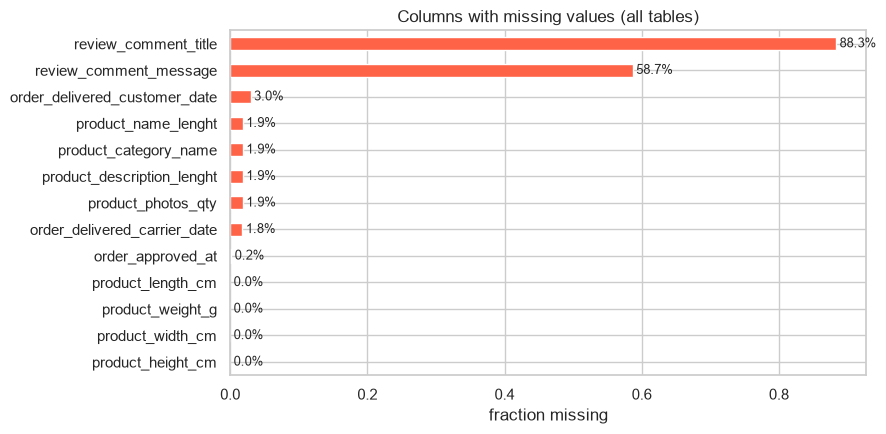

In [6]:
# Missing values across all tables in one view
miss = pd.concat(
    [dfs[k].isna().mean().rename(k) for k in dfs]
).rename("null_frac")
miss = miss[miss > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
miss.plot.barh(ax=ax, color="tomato")
ax.set_xlabel("fraction missing")
ax.set_title("Columns with missing values (all tables)")
ax.invert_yaxis()
for i, v in enumerate(miss):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()


**Observations**

- Only a handful of columns have nulls. Review comment titles/messages are mostly empty (customers rarely write text), and the delivery timestamps in `orders` are null for orders that never reached that stage (cancelled, still shipping, etc.).
- `geolocation` is the only table with fully duplicated rows — it contains one row per raw coordinate observation, not one row per zip code.


## 3. Table-by-table EDA

### 3.1 Orders

In [7]:
overview(orders, 'orders')

=== orders: 99,441 rows x 8 cols ===


,dtype,non_null,null_%,n_unique,example
order_id,str,99441,0.00,99441,e481f51cbdc54678b7cc49136f2d6af7
customer_id,str,99441,0.00,99441,9ef432eb6251297304e76186b10a928d
order_status,str,99441,0.00,8,delivered
order_purchase_timestamp,datetime64[us],99441,0.00,98875,2017-10-02 10:56:33
order_approved_at,datetime64[us],99281,0.16,90733,2017-10-02 11:07:15
order_delivered_carrier_date,datetime64[us],97658,1.79,81018,2017-10-04 19:55:00
order_delivered_customer_date,datetime64[us],96476,2.98,95664,2017-10-10 21:25:13
order_estimated_delivery_date,datetime64[us],99441,0.00,459,2017-10-18 00:00:00


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


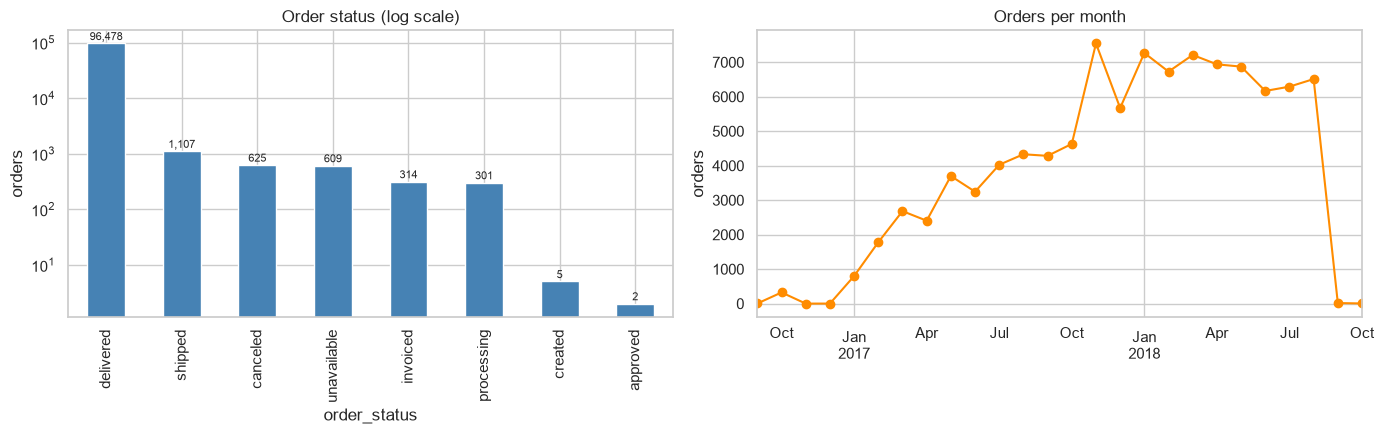

Date range: 2016-09-04 21:15:19  ->  2018-10-17 17:30:18
Delivered share: 97.0%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

status = orders["order_status"].value_counts()
status.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_yscale("log")
axes[0].set_title("Order status (log scale)")
axes[0].set_ylabel("orders")
for i, v in enumerate(status):
    axes[0].text(i, v * 1.15, f"{v:,}", ha="center", fontsize=8)

monthly = orders.set_index("order_purchase_timestamp").resample("ME").size()
monthly.plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Orders per month")
axes[1].set_ylabel("orders"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

print(f"Date range: {orders.order_purchase_timestamp.min()}  ->  {orders.order_purchase_timestamp.max()}")
print(f"Delivered share: {status['delivered'] / status.sum():.1%}")


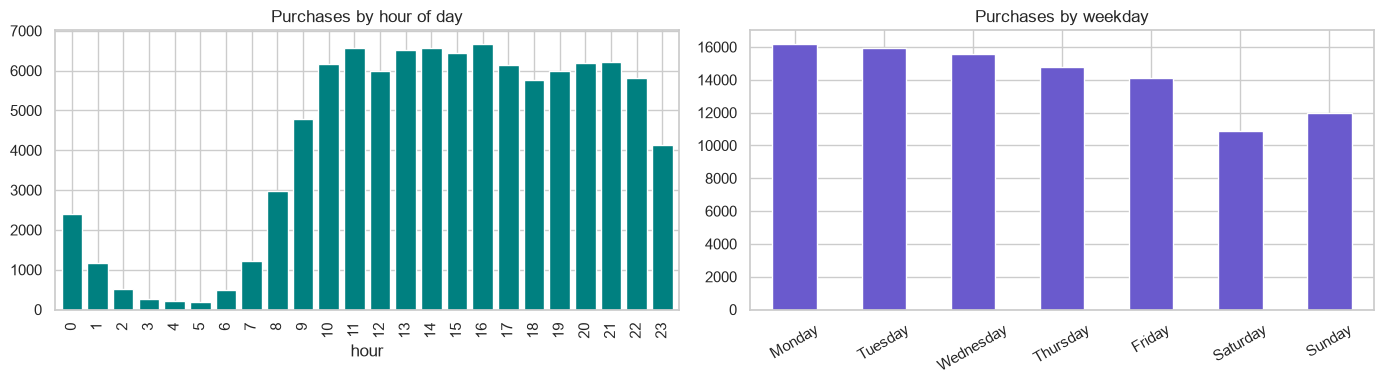

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
purchase_ts = orders["order_purchase_timestamp"]

purchase_ts.dt.hour.value_counts().sort_index().plot.bar(ax=axes[0], color="teal", width=0.8)
axes[0].set_title("Purchases by hour of day"); axes[0].set_xlabel("hour")

dow = purchase_ts.dt.day_name().value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
dow.plot.bar(ax=axes[1], color="slateblue")
axes[1].set_title("Purchases by weekday"); axes[1].set_xlabel("")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


#### Delivery performance

                   count   mean   std     min    25%    50%   75%    max
delivery_days  96,470.00  12.09  9.55    0.00   6.00  10.00 15.00 209.00
estimated_days 96,478.00  23.37  8.76    2.00  18.00  23.00 28.00 155.00
delay_days     96,470.00 -11.88 10.18 -147.00 -17.00 -12.00 -7.00 188.00

Late deliveries: 6.8% of delivered orders


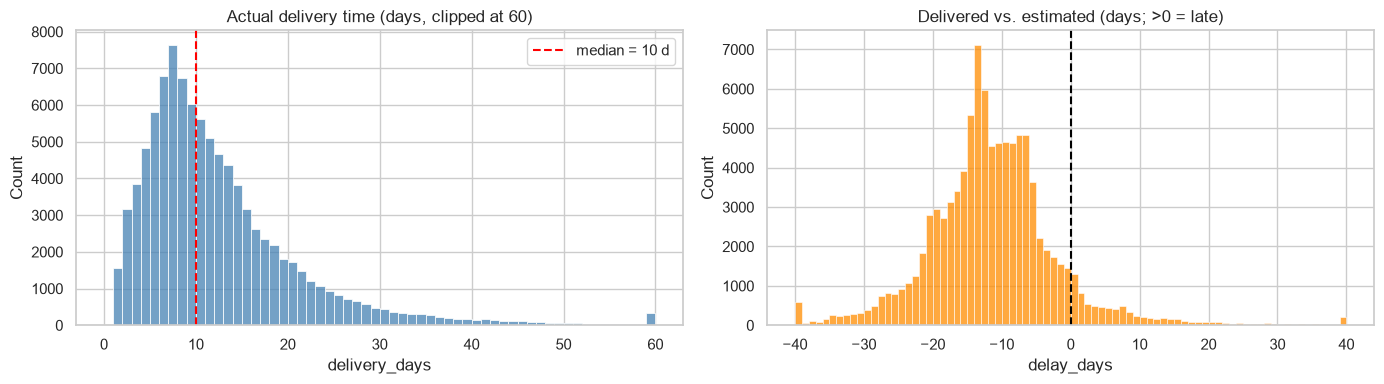

In [10]:
delivered = orders[orders.order_status == "delivered"].copy()
delivered["delivery_days"]  = (delivered.order_delivered_customer_date - delivered.order_purchase_timestamp).dt.days
delivered["estimated_days"] = (delivered.order_estimated_delivery_date - delivered.order_purchase_timestamp).dt.days
delivered["delay_days"]     = (delivered.order_delivered_customer_date - delivered.order_estimated_delivery_date).dt.days
delivered["is_late"]        = delivered["delay_days"] > 0

print(delivered[["delivery_days", "estimated_days", "delay_days"]].describe().T)
print(f"\nLate deliveries: {delivered.is_late.mean():.1%} of delivered orders")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(delivered.delivery_days.clip(upper=60), bins=60, ax=axes[0], color="steelblue")
axes[0].axvline(delivered.delivery_days.median(), color="red", ls="--", label=f"median = {delivered.delivery_days.median():.0f} d")
axes[0].set_title("Actual delivery time (days, clipped at 60)"); axes[0].legend()

sns.histplot(delivered.delay_days.clip(-40, 40), bins=80, ax=axes[1], color="darkorange")
axes[1].axvline(0, color="black", ls="--")
axes[1].set_title("Delivered vs. estimated (days; >0 = late)")
plt.tight_layout(); plt.show()


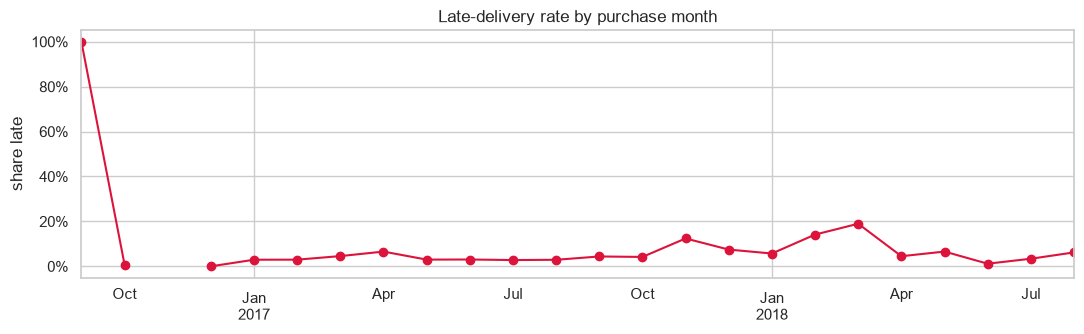

In [11]:
# Late-delivery rate over time
late_m = delivered.set_index("order_purchase_timestamp").resample("ME")["is_late"].mean()
fig, ax = plt.subplots(figsize=(11, 3.5))
late_m.plot(ax=ax, marker="o", color="crimson")
ax.set_ylabel("share late"); ax.set_xlabel("")
ax.set_title("Late-delivery rate by purchase month")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout(); plt.show()


### 3.2 Order items

In [12]:
overview(items, 'order_items')

=== order_items: 112,650 rows x 7 cols ===


,dtype,non_null,null_%,n_unique,example
order_id,str,112650,0.00,98666,00010242fe8c5a6d1ba2dd792cb16214
order_item_id,int64,112650,0.00,21,1
product_id,str,112650,0.00,32951,4244733e06e7ecb4970a6e2683c13e61
seller_id,str,112650,0.00,3095,48436dade18ac8b2bce089ec2a041202
shipping_limit_date,datetime64[us],112650,0.00,93318,2017-09-19 09:45:35
price,float64,112650,0.00,5968,58.90
freight_value,float64,112650,0.00,6999,13.29


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87


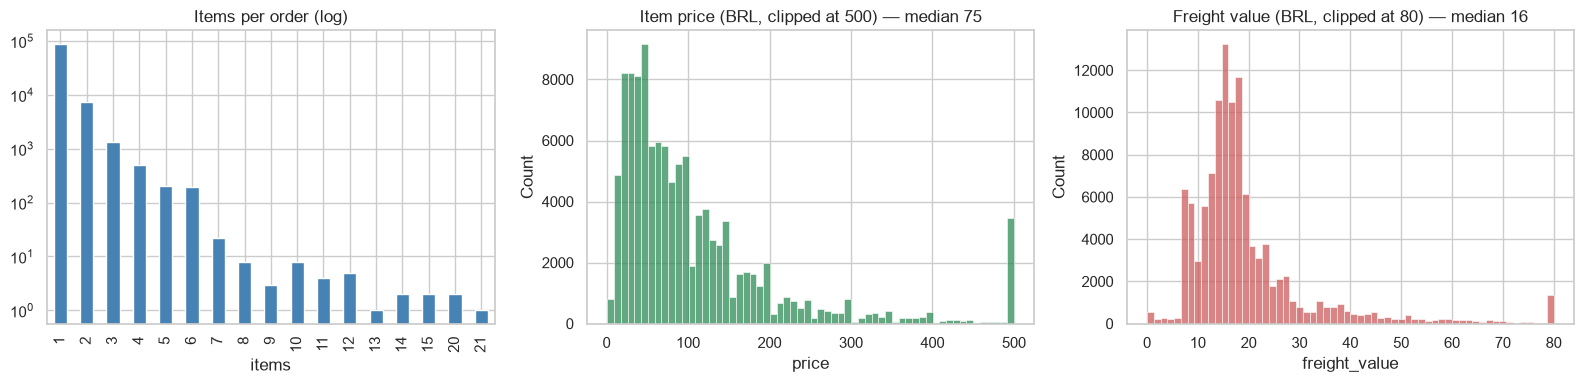

                   count   mean    std  min   25%   50%    75%      max
price         112,650.00 120.65 183.63 0.85 39.90 74.99 134.90 6,735.00
freight_value 112,650.00  19.99  15.81 0.00 13.08 16.26  21.15   409.68

Single-item orders: 90.1%
Freight as share of price (median): 23.1%


In [13]:
items_per_order = items.groupby("order_id")["order_item_id"].max()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
items_per_order.value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_yscale("log"); axes[0].set_title("Items per order (log)"); axes[0].set_xlabel("items")

sns.histplot(items.price.clip(upper=500), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title(f"Item price (BRL, clipped at 500) — median {items.price.median():.0f}")

sns.histplot(items.freight_value.clip(upper=80), bins=60, ax=axes[2], color="indianred")
axes[2].set_title(f"Freight value (BRL, clipped at 80) — median {items.freight_value.median():.0f}")
plt.tight_layout(); plt.show()

print(items[["price", "freight_value"]].describe().T)
print(f"\nSingle-item orders: {(items_per_order == 1).mean():.1%}")
print(f"Freight as share of price (median): {(items.freight_value / items.price).median():.1%}")


### 3.3 Products

In [14]:
overview(products, 'products')

=== products: 32,951 rows x 9 cols ===


,dtype,non_null,null_%,n_unique,example
product_id,str,32951,0.00,32951,1e9e8ef04dbcff4541ed26657ea517e5
product_category_name,str,32341,1.85,73,perfumaria
product_name_lenght,float64,32341,1.85,66,40.00
product_description_lenght,float64,32341,1.85,2960,287.00
product_photos_qty,float64,32341,1.85,19,1.00
product_weight_g,float64,32949,0.01,2204,225.00
product_length_cm,float64,32949,0.01,99,16.00
product_height_cm,float64,32949,0.01,102,10.00
product_width_cm,float64,32949,0.01,95,14.00


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00


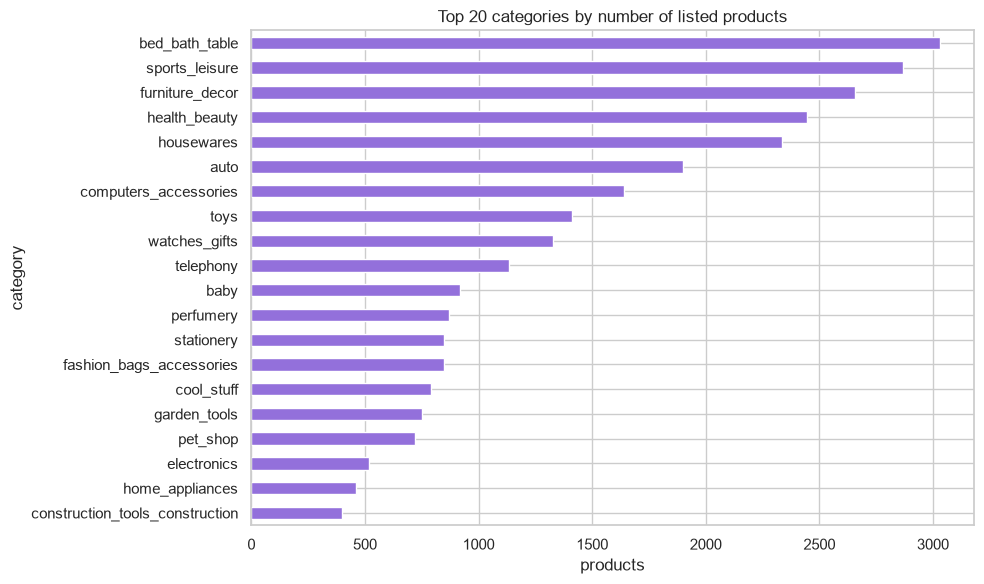

Distinct categories: 73 raw -> 71 after cleaning
Products with no category: 610 (1.9%)
Categories still without an English name: []


In [15]:
products_en = products.merge(cat_tr, on="product_category_name", how="left")

manual_tr = { # missing from raw data
    "pc_gamer": "pc_gamer",
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_preparers",
}
merge_map = {
    "home_confort":      "home_comfort",
    "home_comfort_2":    "home_comfort",
    "home_appliances_2": "home_appliances",
}
products_en["category"] = (products_en["product_category_name_english"]
                           .fillna(products_en["product_category_name"].map(manual_tr))
                           .fillna(products_en["product_category_name"])   # last-resort: keep Portuguese
                           .replace(merge_map))

top_cat = products_en["category"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_cat.plot.barh(ax=ax, color="mediumpurple")
ax.invert_yaxis(); ax.set_title("Top 20 categories by number of listed products"); ax.set_xlabel("products")
plt.tight_layout(); plt.show()

print(f"Distinct categories: {products.product_category_name.nunique()} raw -> {products_en.category.nunique()} after cleaning")
print(f"Products with no category: {products_en.category.isna().sum():,} ({products_en.category.isna().mean():.1%})")
still_pt = set(products_en.category.dropna()) - set(cat_tr.product_category_name_english) - set(manual_tr.values()) - set(merge_map.values())
print("Categories still without an English name:", sorted(still_pt))   # expect []

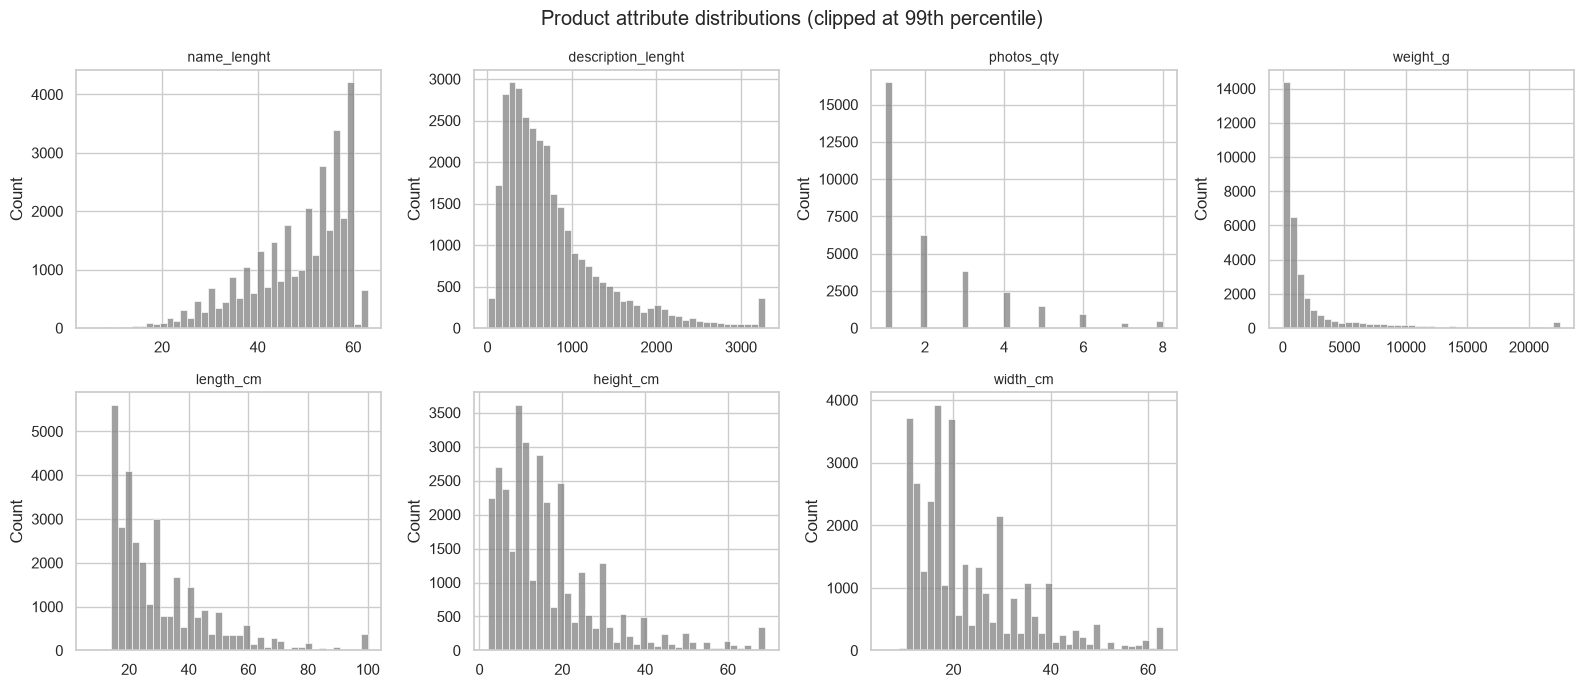

                               count     mean      std  min    25%    50%      75%       max
product_name_lenght        32,341.00    48.48    10.25 5.00  42.00  51.00    57.00     76.00
product_description_lenght 32,341.00   771.50   635.12 4.00 339.00 595.00   972.00  3,992.00
product_photos_qty         32,341.00     2.19     1.74 1.00   1.00   1.00     3.00     20.00
product_weight_g           32,949.00 2,276.47 4,282.04 0.00 300.00 700.00 1,900.00 40,425.00
product_length_cm          32,949.00    30.82    16.91 7.00  18.00  25.00    38.00    105.00
product_height_cm          32,949.00    16.94    13.64 2.00   8.00  13.00    21.00    105.00
product_width_cm           32,949.00    23.20    12.08 6.00  15.00  20.00    30.00    118.00


In [16]:
num_cols = ["product_name_lenght", "product_description_lenght", "product_photos_qty",
            "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.flat, num_cols):
    s = products[c].dropna()
    sns.histplot(s.clip(upper=s.quantile(0.99)), bins=40, ax=ax, color="gray")
    ax.set_title(c.replace("product_", ""), fontsize=10); ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Product attribute distributions (clipped at 99th percentile)")
plt.tight_layout(); plt.show()

print(products[num_cols].describe().T)


### 3.4 Customers

In [17]:
overview(customers, 'customers')

=== customers: 99,441 rows x 5 cols ===


,dtype,non_null,null_%,n_unique,example
customer_id,str,99441,0.00,99441,06b8999e2fba1a1fbc88172c00ba8bc7
customer_unique_id,str,99441,0.00,96096,861eff4711a542e4b93843c6dd7febb0
customer_zip_code_prefix,int64,99441,0.00,14994,14409
customer_city,str,99441,0.00,4119,franca
customer_state,str,99441,0.00,27,SP


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


customer_id (one per order):        99,441
customer_unique_id (actual people):  96,096
Repeat customers (>1 order):        2,997 (3.1%)


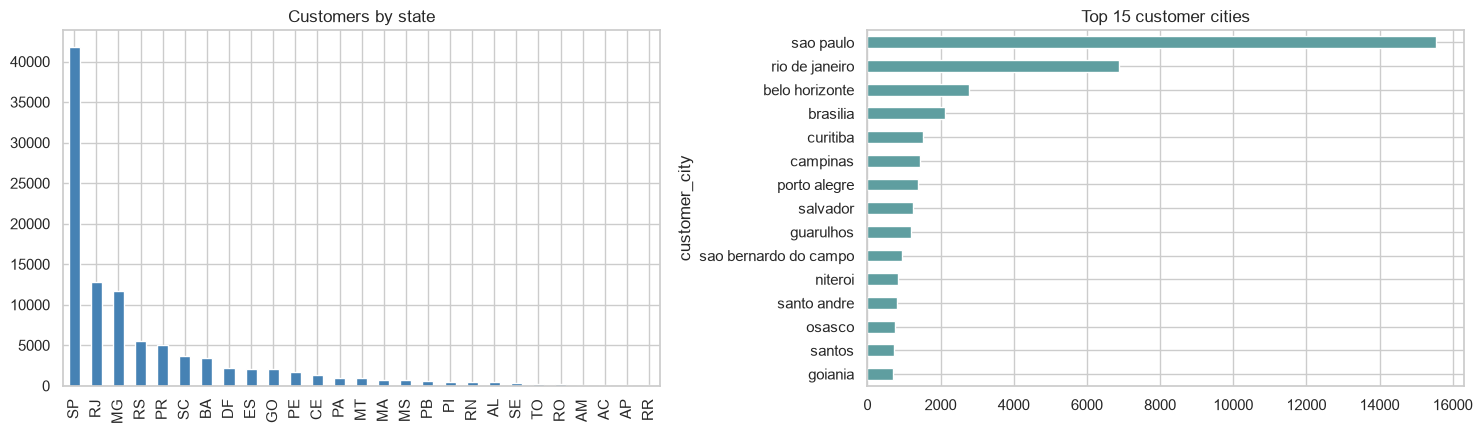

In [18]:
print(f"customer_id (one per order):        {customers.customer_id.nunique():,}")
print(f"customer_unique_id (actual people):  {customers.customer_unique_id.nunique():,}")
orders_per_person = customers.customer_unique_id.value_counts()
print(f"Repeat customers (>1 order):        {(orders_per_person > 1).sum():,} ({(orders_per_person > 1).mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
customers.customer_state.value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Customers by state"); axes[0].set_xlabel("")

customers.customer_city.value_counts().head(15).plot.barh(ax=axes[1], color="cadetblue")
axes[1].invert_yaxis(); axes[1].set_title("Top 15 customer cities")
plt.tight_layout(); plt.show()


### 3.5 Sellers

In [19]:
overview(sellers, 'sellers')

=== sellers: 3,095 rows x 4 cols ===


,dtype,non_null,null_%,n_unique,example
seller_id,str,3095,0.00,3095,3442f8959a84dea7ee197c632cb2df15
seller_zip_code_prefix,int64,3095,0.00,2246,13023
seller_city,str,3095,0.00,611,campinas
seller_state,str,3095,0.00,23,SP


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


          count     mean       std  min    25%    50%      75%        max
orders 3,095.00    32.31    105.14 1.00   2.00   6.00    21.50   1,854.00
items  3,095.00    36.40    119.19 1.00   2.00   8.00    24.00   2,033.00
GMV    3,095.00 4,391.48 13,922.00 3.50 208.85 821.48 3,280.83 229,472.63


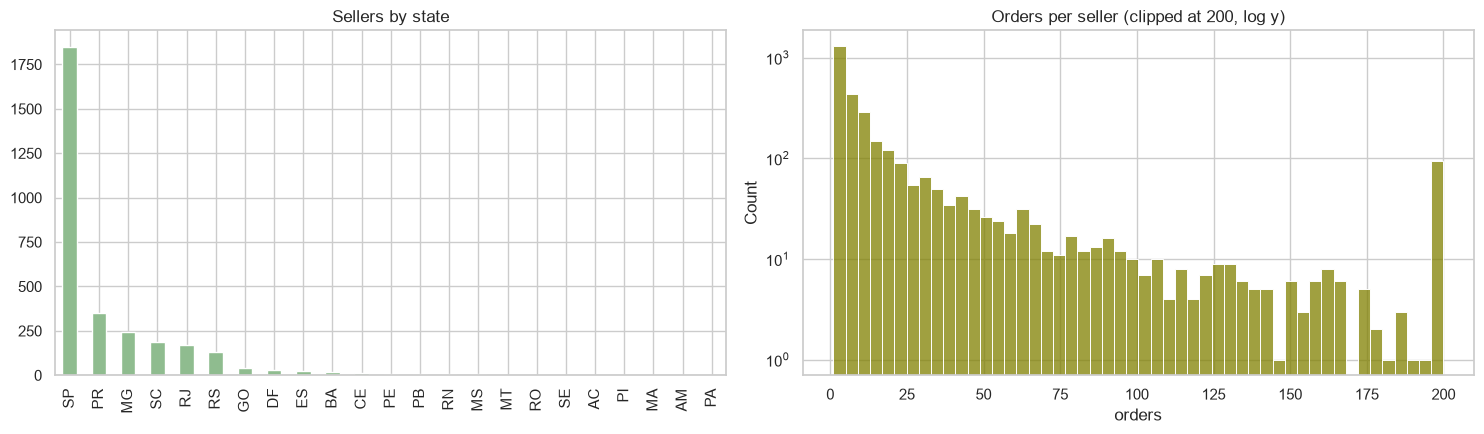

59.7% from SP
11.3% from PR
7.9% from MG
Top 10% of sellers generate 68% of item GMV


In [20]:
seller_stats = items.groupby("seller_id").agg(orders=("order_id", "nunique"),
                                              items=("order_item_id", "size"),
                                              GMV=("price", "sum"))
print(seller_stats.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sellers.seller_state.value_counts().plot.bar(ax=axes[0], color="darkseagreen")
axes[0].set_title("Sellers by state"); axes[0].set_xlabel("")

sns.histplot(seller_stats.orders.clip(upper=200), bins=50, ax=axes[1], color="olive")
axes[1].set_yscale("log"); axes[1].set_title("Orders per seller (clipped at 200, log y)")
plt.tight_layout(); plt.show()

total_sellers = sellers["seller_id"].nunique()
state_counts = sellers.groupby("seller_state")["seller_id"].nunique().sort_values(ascending=False)
for state, count in state_counts.head(3).items():
    print(f"{count / total_sellers:.1%} from {state}")

share = seller_stats.GMV.sort_values(ascending=False).cumsum() / seller_stats.GMV.sum()
print(f"Top 10% of sellers generate {share.iloc[int(len(share)*0.1)]:.0%} of item GMV")

### 3.6 Payments

In [21]:
overview(payments, 'payments')

=== payments: 103,886 rows x 5 cols ===


,dtype,non_null,null_%,n_unique,example
order_id,str,103886,0.00,99440,b81ef226f3fe1789b1e8b2acac839d17
payment_sequential,int64,103886,0.00,29,1
payment_type,str,103886,0.00,5,credit_card
payment_installments,int64,103886,0.00,24,8
payment_value,float64,103886,0.00,29077,99.33


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


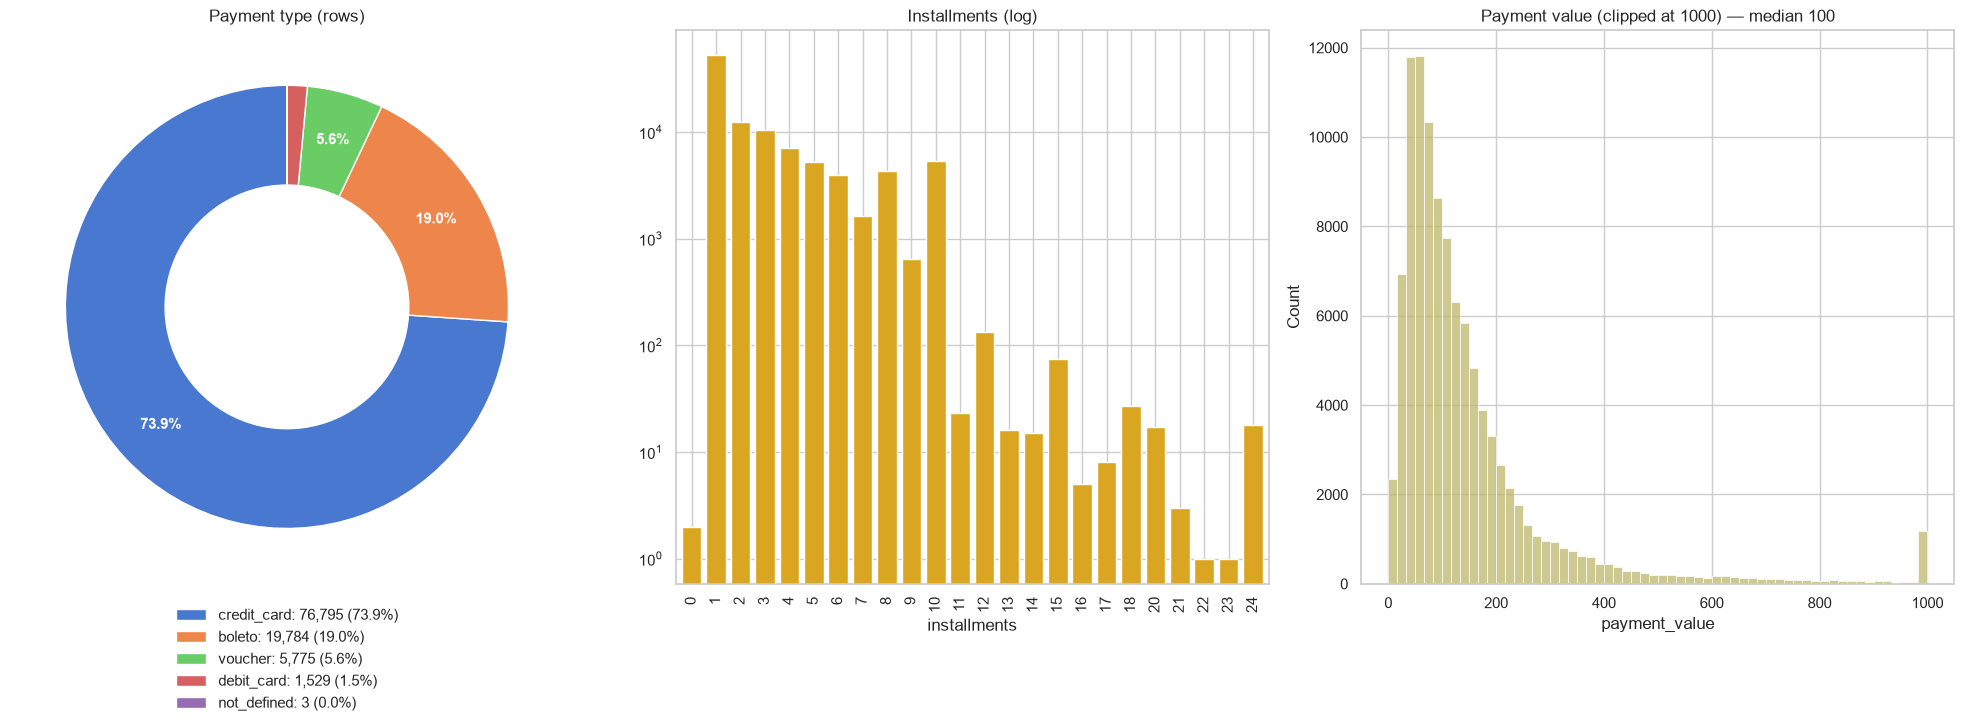

Orders with more than one payment record: 3,039 (3.1%)

Mean value & installments by payment type:
                  n  mean_value  mean_installments
payment_type                                      
boleto        19784      145.03               1.00
credit_card   76795      163.32               3.51
debit_card     1529      142.57               1.00
not_defined       3        0.00               1.00
voucher        5775       65.70               1.00


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

pt = payments.payment_type.value_counts()
share = pt / pt.sum()
wedges, *_ = axes[0].pie(
    pt, startangle=90, colors=sns.color_palette("muted"),
    wedgeprops=dict(width=0.45, edgecolor="white"),
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",     # skip labels on slivers
    pctdistance=0.78,
    textprops=dict(color="white", fontsize=11, weight="bold"),
)
axes[0].legend(wedges,
               [f"{k}: {v:,} ({s:.1%})" for k, v, s in zip(pt.index, pt, share)],
               loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=False)
axes[0].set_title("Payment type (rows)")

payments.payment_installments.value_counts().sort_index().plot.bar(ax=axes[1], color="goldenrod", width=0.8)
axes[1].set_yscale("log"); axes[1].set_title("Installments (log)"); axes[1].set_xlabel("installments")

sns.histplot(payments.payment_value.clip(upper=1000), bins=60, ax=axes[2], color="darkkhaki")
axes[2].set_title(f"Payment value (clipped at 1000) — median {payments.payment_value.median():.0f}")
plt.tight_layout(); plt.show()

multi = payments.groupby("order_id").payment_sequential.max()
print(f"Orders with more than one payment record: {(multi > 1).sum():,} ({(multi > 1).mean():.1%})")
print("\nMean value & installments by payment type:")
print(payments.groupby("payment_type").agg(n=("order_id", "size"),
                                            mean_value=("payment_value", "mean"),
                                            mean_installments=("payment_installments", "mean")))


In [23]:
# check what are the orders within undefined payment type using order id
orders[orders['order_id'].isin(payments['order_id'][payments['payment_type']=='not_defined'])]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaT,NaT,NaT,2018-09-12
39919,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,canceled,2018-09-03 14:14:25,NaT,NaT,NaT,2018-09-10
40235,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,canceled,2018-08-28 20:05:14,NaT,NaT,NaT,2018-09-11


Orders where payments = price + freight (±R$0.02): 99.73%
Orders with items but NO payment record: 1

Mismatched orders: 267  (overpaid: 244, underpaid: 23)
Median overpayment: R$ 7.11   max: R$ 182.81
Share with >1 installment:  mismatched 93%  vs all orders 52%
Share involving a voucher:  mismatched 3%  vs all orders 4%

Payments total            R$    16,008,872
= GMV + freight       R$    15,843,553   (orders with items)
+ payments, item-less     R$       162,592   (the 775 unavailable/cancelled orders, Sec. 4)
+ net financing/adjust.   R$         2,870


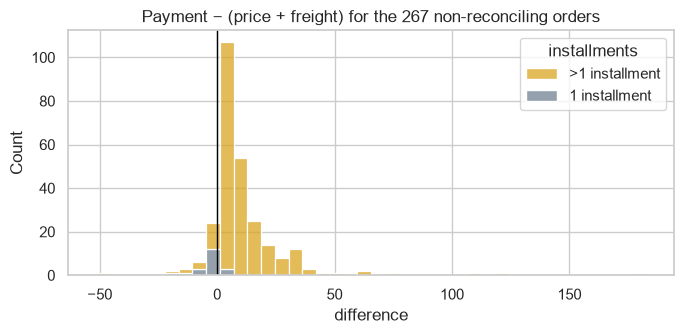

In [24]:
# --- 3.6b Reconciliation: does the payments table equal price + freight (from order info)? ---
order_pf  = items.groupby("order_id").agg(basket=("price", "sum"), freight=("freight_value", "sum"))
order_pay = payments.groupby("order_id").agg(paid=("payment_value", "sum"),
                                             installments=("payment_installments", "max"),
                                             has_voucher=("payment_type", lambda s: (s == "voucher").any()))
rec = order_pf.join(order_pay, how="left")
rec["pf"]   = rec.basket + rec.freight
rec["diff"] = (rec.paid - rec.pf).round(2)

# claim 1: near-perfect reconciliation
match = rec["diff"].abs() <= 0.02
print(f"Orders where payments = price + freight (±R$0.02): {match.mean():.2%}")
print(f"Orders with items but NO payment record: {rec.paid.isna().sum()}")

# claim 2: the mismatches are installment financing charges, not vouchers
mm = rec[rec["diff"].abs() > 0.02]
print(f"\nMismatched orders: {len(mm)}  (overpaid: {(mm['diff'] > 0).sum()}, underpaid: {(mm['diff'] < 0).sum()})")
print(f"Median overpayment: R$ {mm.loc[mm['diff'] > 0, 'diff'].median():.2f}   max: R$ {mm['diff'].max():.2f}")
print(f"Share with >1 installment:  mismatched {(mm.installments > 1).mean():.0%}  vs all orders {(rec.installments > 1).mean():.0%}")
print(f"Share involving a voucher:  mismatched {mm.has_voucher.mean():.0%}  vs all orders {rec.has_voucher.mean():.0%}")

# claim 3: totals reconcile once item-less orders are added back
no_item_pay = payments.loc[~payments.order_id.isin(items.order_id), "payment_value"].sum()
print(f"\nPayments total            R$ {payments.payment_value.sum():>13,.0f}")
print(f"= GMV + freight       R$ {rec.pf.sum():>13,.0f}   (orders with items)")
print(f"+ payments, item-less     R$ {no_item_pay:>13,.0f}   (the 775 unavailable/cancelled orders, Sec. 4)")
print(f"+ net financing/adjust.   R$ {rec['diff'].sum():>13,.0f}")

# visual: the overpayment concentrates in multi-installment credit orders
plot_df = pd.DataFrame({
    "diff": mm["diff"],
    "installments": (mm.installments > 1).map({True: ">1 installment", False: "1 installment"}),
})

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(data=plot_df, x="diff", hue="installments", bins=40,
             multiple="stack", ax=ax, palette=["goldenrod", "slategray"])
ax.axvline(0, color="black", lw=1)
ax.set_title(f"Payment − (price + freight) for the {len(mm)} non-reconciling orders")
ax.set_xlabel("difference")
plt.tight_layout(); plt.show()

### 3.7 Reviews

In [25]:
overview(reviews, 'reviews')

=== reviews: 99,224 rows x 7 cols ===


,dtype,non_null,null_%,n_unique,example
review_id,str,99224,0.00,98410,7bc2406110b926393aa56f80a40eba40
order_id,str,99224,0.00,98673,73fc7af87114b39712e6da79b0a377eb
review_score,int64,99224,0.00,5,4
review_comment_title,str,11568,88.34,4527,NaN
review_comment_message,str,40977,58.70,36159,NaN
review_creation_date,datetime64[us],99224,0.00,636,2018-01-18 00:00:00
review_answer_timestamp,datetime64[us],99224,0.00,98248,2018-01-18 21:46:59


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24


All review information without addressing duplicated issues

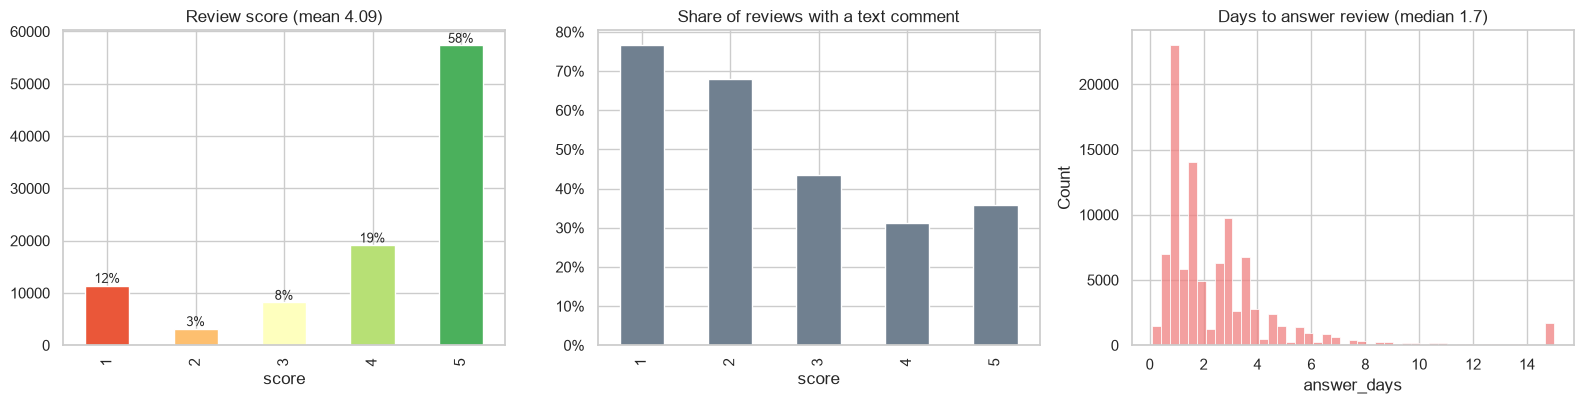

Unique review_id: 98,410 / 99,224 rows
Unique order_id:  98,673  -> some orders have multiple reviews, some review_ids cover multiple orders


In [26]:
reviews["has_title"] = reviews.review_comment_title.notna()
reviews["has_message"] = reviews.review_comment_message.notna()
reviews["answer_days"] = (reviews.review_answer_timestamp - reviews.review_creation_date).dt.total_seconds() / 86400

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sc = reviews.review_score.value_counts().sort_index()
sc.plot.bar(ax=axes[0], color=sns.color_palette("RdYlGn", 5))
axes[0].set_title(f"Review score (mean {reviews.review_score.mean():.2f})"); axes[0].set_xlabel("score")
for i, v in enumerate(sc):
    axes[0].text(i, v + 500, f"{v/sc.sum():.0%}", ha="center", fontsize=9)

reviews.groupby("review_score").has_message.mean().plot.bar(ax=axes[1], color="slategray")
axes[1].set_title("Share of reviews with a text comment"); axes[1].set_xlabel("score")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

sns.histplot(reviews.answer_days.clip(upper=15), bins=45, ax=axes[2], color="lightcoral")
axes[2].set_title(f"Days to answer review (median {reviews.answer_days.median():.1f})")
plt.tight_layout(); plt.show()

print(f"Unique review_id: {reviews.review_id.nunique():,} / {len(reviews):,} rows")
print(f"Unique order_id:  {reviews.order_id.nunique():,}  -> some orders have multiple reviews, some review_ids cover multiple orders")


In [27]:
per_order = reviews.order_id.value_counts()
print(f"Orders with >1 review: {(per_order > 1).sum():,}  (max {per_order.max()})")
print(f"review_ids linked to >1 order: {(reviews.review_id.value_counts() > 1).sum():,}")

# one score per order: latest review = customer's final verdict
rev_order = (reviews.sort_values("review_creation_date")
                    .drop_duplicates("order_id", keep="last")
                    [["order_id", "review_score", "review_creation_date"]])
print(f"Per-order mean score: {rev_order.review_score.mean():.2f}  (per-review: {reviews.review_score.mean():.2f})")

Orders with >1 review: 547  (max 3)
review_ids linked to >1 order: 789
Per-order mean score: 4.09  (per-review: 4.09)


In [28]:
# --- Does deduplicating reviews change the descriptive statistics? ---
reviews["has_message"] = reviews.review_comment_message.notna()
reviews["answer_days"] = (reviews.review_answer_timestamp - reviews.review_creation_date).dt.total_seconds() / 86400

views = {
    "raw rows":           reviews,
    "unique review_id":   reviews.drop_duplicates("review_id"),
    "per order (latest)": reviews.sort_values("review_creation_date").drop_duplicates("order_id", keep="last"),
}

def describe(df):
    dist = df.review_score.value_counts(normalize=True).sort_index()
    msg  = df.groupby("review_score").has_message.mean()
    return pd.Series({
        "n":                 len(df),
        "mean score":        df.review_score.mean(),
        "1-star %":          100 * dist[1],
        "5-star %":          100 * dist[5],
        "1-star comment %":  100 * msg[1],
        "5-star comment %":  100 * msg[5],
        "answer days median": df.answer_days.median(),
        "answer days mean":   df.answer_days.mean(),
    })

cmp = pd.DataFrame({k: describe(v) for k, v in views.items()}).T
cmp["n"] = cmp["n"].astype(int)
cmp.round(3)

,n,mean score,1-star %,5-star %,1-star comment %,5-star comment %,answer days median,answer days mean
raw rows,99224,4.09,11.51,57.78,76.55,35.85,1.68,3.15
unique review_id,98410,4.09,11.46,57.83,76.59,35.91,1.67,3.15
per order (latest),98673,4.09,11.52,57.77,76.60,35.88,1.68,3.15


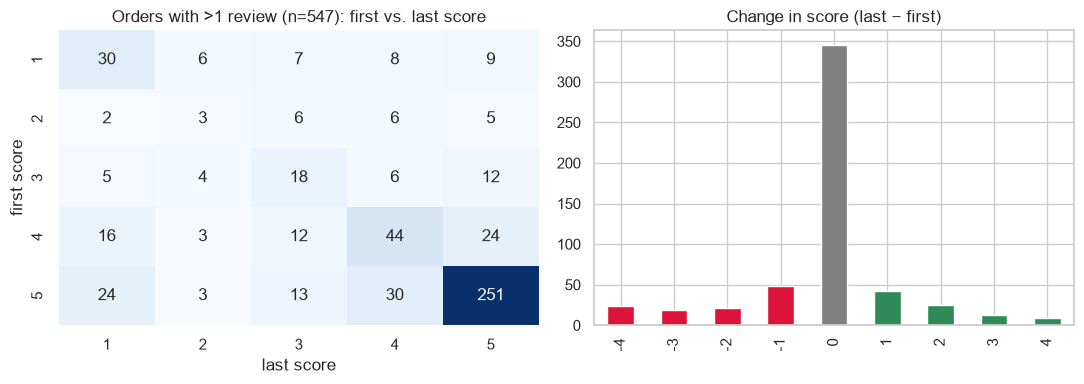

Score changed in 37% of re-reviewed orders; mean first 4.10 → last 3.96
Shared review_ids (one review covering several orders): 789 — score identical across their orders in all cases


In [29]:
# --- Orders reviewed more than once: does the score change? ---
multi_ids = reviews.order_id.value_counts().loc[lambda s: s > 1].index
m = (reviews[reviews.order_id.isin(multi_ids)]
     .sort_values("review_creation_date")
     .groupby("order_id").review_score.agg(first="first", last="last"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ct = pd.crosstab(m["first"], m["last"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title(f"Orders with >1 review (n={len(m):,}): first vs. last score")
axes[0].set_xlabel("last score"); axes[0].set_ylabel("first score")

delta = (m["last"] - m["first"]).value_counts().sort_index()
delta.plot.bar(ax=axes[1], color=["crimson" if d < 0 else "seagreen" if d > 0 else "gray" for d in delta.index])
axes[1].set_title("Change in score (last − first)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

changed = (m["first"] != m["last"]).mean()
print(f"Score changed in {changed:.0%} of re-reviewed orders; mean first {m['first'].mean():.2f} → last {m['last'].mean():.2f}")
print(f"Shared review_ids (one review covering several orders): "
      f"{(reviews.review_id.value_counts() > 1).sum():,} — score identical across their orders in all cases")

814 duplicated reviews (789 review_ids with 1 review_id used for multiple orders) \
547 orders with > 1 review (re-review after some time), 37% of these change the score \
These comprises of 1.38% of all rows and modifying them changes distribution by < 0.1 percentage points \
For order-level analysis and modelling, reviews are joined at order grain — where the 814 shared-id rows are distinct orders and are kept — and the 547 orders with multiple reviews take the latest review as their score.

### 3.8 Geolocation

In [30]:
overview(geo, 'geolocation')

=== geolocation: 1,000,163 rows x 5 cols ===


,dtype,non_null,null_%,n_unique,example
geolocation_zip_code_prefix,int64,1000163,0.00,19015,1037
geolocation_lat,float64,1000163,0.00,717360,-23.55
geolocation_lng,float64,1000163,0.00,717613,-46.64
geolocation_city,str,1000163,0.00,8011,sao paulo
geolocation_state,str,1000163,0.00,27,SP


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP


Rows: 1,000,163   unique zip prefixes: 19,015   exact duplicate rows: 261,831
Lat range: -36.61 to 45.07   Lng range: -101.47 to 121.11
Coordinates outside Brazil's bounding box: 42


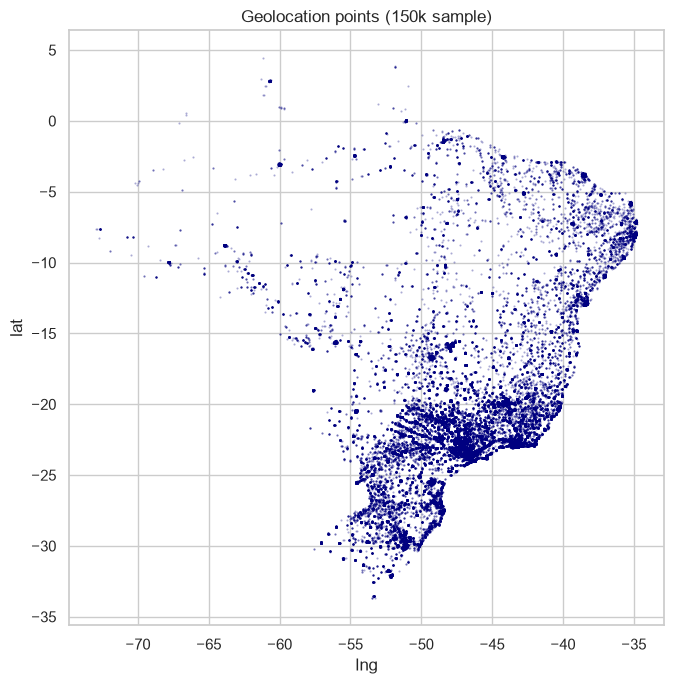

In [31]:
print(f"Rows: {len(geo):,}   unique zip prefixes: {geo.geolocation_zip_code_prefix.nunique():,}   exact duplicate rows: {geo.duplicated().sum():,}")
print(f"Lat range: {geo.geolocation_lat.min():.2f} to {geo.geolocation_lat.max():.2f}   Lng range: {geo.geolocation_lng.min():.2f} to {geo.geolocation_lng.max():.2f}")

# Brazil's bounding box (approx): lat -34 .. 6, lng -74 .. -34
in_br = geo.geolocation_lat.between(-34, 6) & geo.geolocation_lng.between(-74, -34)
print(f"Coordinates outside Brazil's bounding box: {(~in_br).sum():,}")

sample = geo[in_br].sample(150_000, random_state=0)
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample.geolocation_lng, sample.geolocation_lat, s=0.3, alpha=0.3, c="navy")
ax.set_title("Geolocation points (150k sample)"); ax.set_xlabel("lng"); ax.set_ylabel("lat")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()


In [32]:
# One coordinate per zip prefix (median), used later for mapping customers & sellers
geo_zip = (geo[in_br].groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]]
           .median().rename(columns={"geolocation_lat": "lat", "geolocation_lng": "lng"}))
print(f"Zip prefixes with coordinates: {len(geo_zip):,}")
print(f"Customer zips covered: {customers.customer_zip_code_prefix.isin(geo_zip.index).mean():.1%}")
print(f"Seller zips covered:   {sellers.seller_zip_code_prefix.isin(geo_zip.index).mean():.1%}")


Zip prefixes with coordinates: 19,010
Customer zips covered: 99.7%
Seller zips covered:   99.8%


### 3.9 Category name translation

In [33]:
overview(cat_tr, 'category_translation', n=5)
print("Translations never used by any product:",
      sorted(set(cat_tr.product_category_name) - set(products.product_category_name.dropna())))


=== category_translation: 71 rows x 2 cols ===


,dtype,non_null,null_%,n_unique,example
product_category_name,str,71,0.00,71,beleza_saude
product_category_name_english,str,71,0.00,71,health_beauty


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translations never used by any product: []


## 4. How the tables link together

In [34]:
def check(label, child, child_key, parent, parent_key):
    matched = child[child_key].isin(parent[parent_key])
    return {"relationship": label, "child_rows": len(child), "matched_%": 100 * matched.mean(),
            "orphans": int((~matched).sum())}

checks = pd.DataFrame([
    check("orders.customer_id -> customers",      orders,   "customer_id", customers, "customer_id"),
    check("order_items.order_id -> orders",       items,    "order_id",    orders,    "order_id"),
    check("order_items.product_id -> products",   items,    "product_id",  products,  "product_id"),
    check("order_items.seller_id -> sellers",     items,    "seller_id",   sellers,   "seller_id"),
    check("payments.order_id -> orders",          payments, "order_id",    orders,    "order_id"),
    check("reviews.order_id -> orders",           reviews,  "order_id",    orders,    "order_id"),
    check("products.category -> translation",    products.dropna(subset=["product_category_name"]),
                                                            "product_category_name", cat_tr, "product_category_name"),
    check("customers.zip -> geolocation",         customers, "customer_zip_code_prefix", geo, "geolocation_zip_code_prefix"),
    check("sellers.zip -> geolocation",           sellers,   "seller_zip_code_prefix",   geo, "geolocation_zip_code_prefix"),
]).set_index("relationship")

checks["matched_%"] = checks["matched_%"].round(2)
checks

,child_rows,matched_%,orphans
relationship,,,
orders.customer_id -> customers,99441,100.00,0
order_items.order_id -> orders,112650,100.00,0
order_items.product_id -> products,112650,100.00,0
order_items.seller_id -> sellers,112650,100.00,0
payments.order_id -> orders,103886,100.00,0
reviews.order_id -> orders,99224,100.00,0
products.category -> translation,32341,99.96,13
customers.zip -> geolocation,99441,99.72,278
sellers.zip -> geolocation,3095,99.77,7


In [35]:
# Coverage the other way round: which orders lack items / payments / reviews?
cov = pd.DataFrame({
    "has_items":    orders.order_id.isin(items.order_id).values,
    "has_payment":  orders.order_id.isin(payments.order_id).values,
    "has_review":   orders.order_id.isin(reviews.order_id).values,
}, index=orders.order_id)
print((100 * cov.mean()).round(2).rename("% of orders"))
print("\nOrders without items, by status:")
print(orders[~cov.has_items.values].order_status.value_counts())


has_items      99.22
has_payment   100.00
has_review     99.23
Name: % of orders, dtype: float64

Orders without items, by status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


The 775 items

In [36]:
# ---- Orders with no line items (excluded from the consolidated dataset) ----
no_items = orders[~orders.order_id.isin(items.order_id)].copy()
print(f"{len(no_items):,} orders have no rows in order_items  "
      f"({orders.order_id.nunique():,} - {len(no_items)} = {items.order_id.nunique():,} in the consolidated dataset)")

print("\nStatus:")
print(no_items.order_status.value_counts())

print("\nHow far each got through the pipeline (% with timestamp):")
print((100 * no_items[["order_approved_at", "order_delivered_carrier_date",
                       "order_delivered_customer_date"]].notna().mean()).round(1))

# Payments and reviews attached to them
ni_pay = payments[payments.order_id.isin(no_items.order_id)]
ni_rev = reviews[reviews.order_id.isin(no_items.order_id)]
print(f"\nWith a payment record: {no_items.order_id.isin(payments.order_id).mean():.1%}   "
      f"total paid: R$ {ni_pay.payment_value.sum():,.0f}   median: R$ {ni_pay.payment_value.median():.2f}")
print(f"With a review:         {no_items.order_id.isin(reviews.order_id).mean():.1%}   "
      f"mean score: {ni_rev.review_score.mean():.2f}  (all orders: {reviews.review_score.mean():.2f})")
print("Score distribution:", ni_rev.review_score.value_counts().sort_index().to_dict())

775 orders have no rows in order_items  (99,441 - 775 = 98,666 in the consolidated dataset)

Status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

How far each got through the pipeline (% with timestamp):
order_approved_at               81.20
order_delivered_carrier_date     0.10
order_delivered_customer_date    0.00
dtype: float64

With a payment record: 100.0%   total paid: R$ 162,592   median: R$ 98.22
With a review:         97.5%   mean score: 1.73  (all orders: 4.09)
Score distribution: {1: 540, 2: 62, 3: 53, 4: 33, 5: 71}


In [37]:
no_items_detail = (no_items[["order_id", "order_status", "order_purchase_timestamp", "order_approved_at"]]
    .merge(ni_pay.groupby("order_id").agg(payment_type=("payment_type", "first"),
                                          paid=("payment_value", "sum")), on="order_id", how="left")
    .merge(ni_rev[["order_id", "review_score", "review_comment_message"]], on="order_id", how="left")
    .sort_values("order_purchase_timestamp"))

pd.set_option("display.max_colwidth", 120)
no_items_detail                     # all 775 rows (778 after the review join — a few orders have 2 reviews)

,order_id,order_status,order_purchase_timestamp,order_approved_at,payment_type,paid,review_score,review_comment_message
77,809a282bbd5dbcabb6f2f724fca862ec,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,credit_card,40.95,1.00,MEU PEDIDO NÃO FOI ENTREGUE E NÃO FOI DADA NENHUMA SATISTAÇÃO
600,1aecadf4362edaca7fa033e882076c8d,canceled,2016-10-04 10:05:45,2016-10-04 10:26:40,credit_card,50.74,2.00,NaN
604,620b0acb9258b51defbc51804c5298d5,canceled,2016-10-04 11:44:01,2016-10-05 08:45:09,credit_card,451.44,1.00,"NÃO ENVIARAM O PRODUTO E NINGUÉM ME DEU JUSTIFICATIVA, NEM PREVISÃO E NO SITE DO stark ESTAVA CONSTANDO COMO ENVIADO..."
18,ddaec6fff982b13e7e048b627a11d6da,canceled,2016-10-04 19:41:32,NaT,boleto,116.99,1.00,"Nunca chegou o produto, deram uma excusa e trocaram o valor porcum vale."
180,a68ce1686d536ca72bd2dadc4b8671e5,shipped,2016-10-05 01:47:40,2016-10-07 03:11:22,boleto,77.73,1.00,Comprei o produto dia 06/10/2016 hj é 15/12/2016 SENDO QUE ERA 38 DIAS DE ENTREGA JÁ FAZEM MAIS DE 60 DIAS E NADA NÃ...
...,...,...,...,...,...,...,...,...
395,392ed9afd714e3c74767d0c4d3e3f477,canceled,2018-09-29 09:13:03,NaT,voucher,137.03,1.00,o produto foi entregue errado eu estou esperado contatos da loja para resolver a situação\r\n
696,616fa7d4871b87832197b2a137a115d2,canceled,2018-10-01 15:30:09,NaT,voucher,80.38,2.00,NaN
247,a2ac6dad85cf8af5b0afb510a240fe8c,canceled,2018-10-03 18:55:29,NaT,voucher,197.55,1.00,quero devolver o produto comprei um veio outro;;;\r\nquero meu dinheiro de volta.
524,b059ee4de278302d550a3035c4cdb740,canceled,2018-10-16 20:16:02,NaT,voucher,222.03,5.00,Os produtos são de boa qualidade e o preço que adquiri foi excelente.


## 5. Cross-table analysis

In [38]:
# Build one analytical frame at order-item grain
df = (items
      .merge(products_en[["product_id", "category", "product_weight_g"]], on="product_id", how="left")
      .merge(orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp",
                     "order_delivered_customer_date", "order_estimated_delivery_date"]], on="order_id", how="left")
      .merge(customers[["customer_id", "customer_unique_id", "customer_state", "customer_city"]], on="customer_id", how="left")
      .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left"))

df["category"]      = df["category"].fillna("unknown")
df["year_month"]    = df.order_purchase_timestamp.dt.to_period("M")
df["day_of_week"]   = df.order_purchase_timestamp.dt.day_name()
df["delivery_days"] = (df.order_delivered_customer_date - df.order_purchase_timestamp).dt.days
df["is_on_time"]    = df.order_delivered_customer_date <= df.order_estimated_delivery_date   # False when undelivered
df["item_total_price"]  = df.price + df.freight_value

full = df   # keep the old name so the rest of Section 5 runs unchanged

n_dropped = orders.order_id.nunique() - df.order_id.nunique()
print(f"{len(df):,} line items across {df.order_id.nunique():,} orders "
      f"({n_dropped} orders had no items and are excluded — see Section 4)")

112,650 line items across 98,666 orders (775 orders had no items and are excluded — see Section 4)


In [40]:
delivered.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'estimated_days', 'delay_days', 'is_late'],
      dtype='str')

In [41]:
order_totals = df.groupby("order_id").price.sum()
# orders_per_person = customers.customer_unique_id.value_counts() computed earlier in Section 3.4

kpis = pd.Series({
    "Orders (with items)":     f"{df.order_id.nunique():,}",
    "Unique customers":        f"{customers.customer_unique_id.nunique():,}",
    "Item GMV (R$)":       f"{df.price.sum():,.0f}",
    "GMV incl. freight":   f"{df.item_total_price.sum():,.0f}",
    "AOV mean / median (R$)":  f"{order_totals.mean():.2f} / {order_totals.median():.2f}",
    "Repeat rate":             f"{(orders_per_person > 1).mean():.1%}",
    "Median delivery days":    f"{delivered.drop_duplicates('order_id').delivery_days.median():.0f}",
    "On-time delivery":        f"{df.drop_duplicates('order_id').is_on_time.mean():.1%}",
    "Avg review score":        f"{reviews.review_score.mean():.2f}",
}, name="value")
kpis.to_frame()

,value
Orders (with items),"98,666"
Unique customers,"96,096"
Item GMV (R$),"13,591,644"
GMV incl. freight,"15,843,553"
AOV mean / median (R$),137.75 / 86.90
Repeat rate,3.1%
Median delivery days,10
On-time delivery,89.8%
Avg review score,4.09


### 5.1 GMV

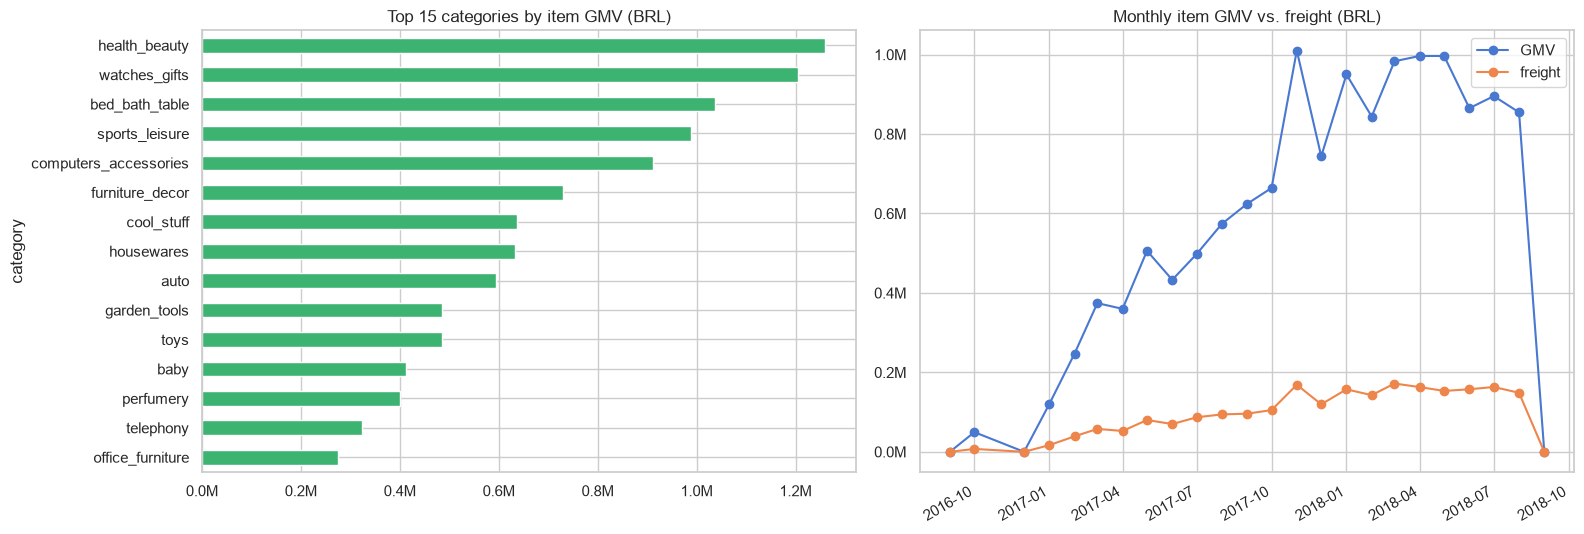

Total item GMV: R$ 13,591,644   total freight: R$ 2,251,910


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

rev_cat = full.groupby("category").price.sum().sort_values(ascending=False).head(15)
rev_cat.plot.barh(ax=axes[0], color="mediumseagreen")
axes[0].invert_yaxis(); axes[0].set_title("Top 15 categories by item GMV (BRL)")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

rev_m = full.groupby("year_month").agg(GMV=("price", "sum"), freight=("freight_value", "sum"))
rev_m.index = rev_m.index.to_timestamp()
rev_m.plot(ax=axes[1], marker="o")
axes[1].set_title("Monthly item GMV vs. freight (BRL)"); axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()

print(f"Total item GMV: R$ {full.price.sum():,.0f}   total freight: R$ {full.freight_value.sum():,.0f}")


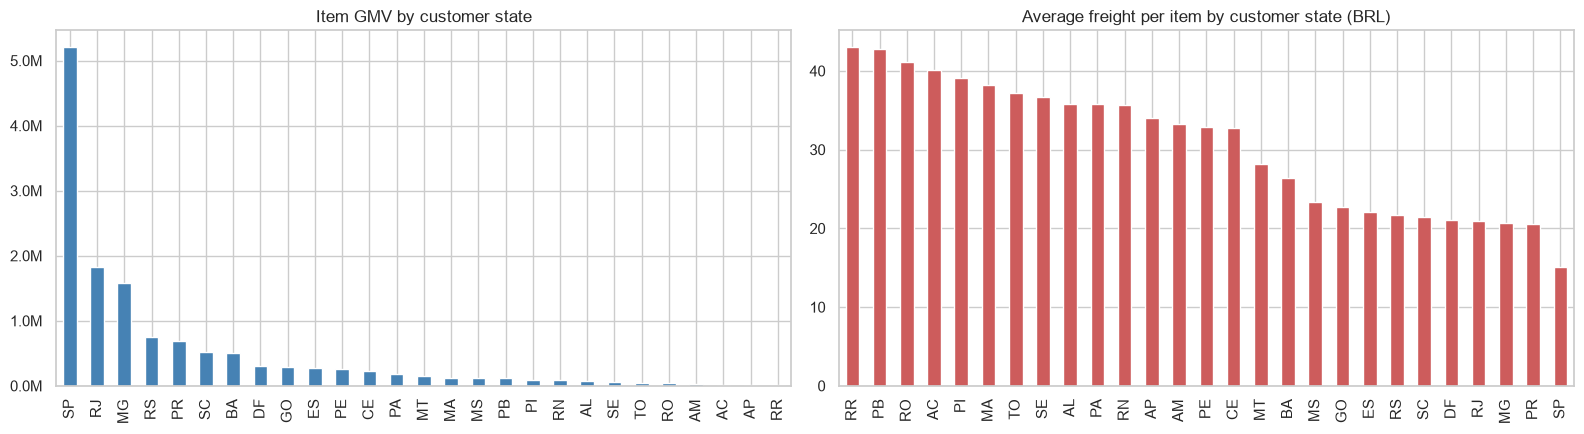

,orders,GMV,avg_freight,GMV_per_order
customer_state,,,,
SP,41375,"5,202,955.05",15.15,125.75
RJ,12762,"1,824,092.67",20.96,142.93
MG,11544,"1,585,308.03",20.63,137.33
RS,5432,"750,304.02",21.74,138.13
PR,4998,"683,083.76",20.53,136.67
SC,3612,"520,553.34",21.47,144.12
BA,3358,"511,349.99",26.36,152.28
DF,2125,"302,603.94",21.04,142.40
GO,2007,"294,591.95",22.77,146.78


In [44]:
state = full.groupby("customer_state").agg(orders=("order_id", "nunique"),
                                            GMV=("price", "sum"),
                                            avg_freight=("freight_value", "mean"))
state["GMV_per_order"] = state.GMV / state.orders
state = state.sort_values("GMV", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
state.GMV.plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Item GMV by customer state"); axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

state.avg_freight.sort_values(ascending=False).plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("Average freight per item by customer state (BRL)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()
state.head(10)


### 5.2 Delivery and reviews

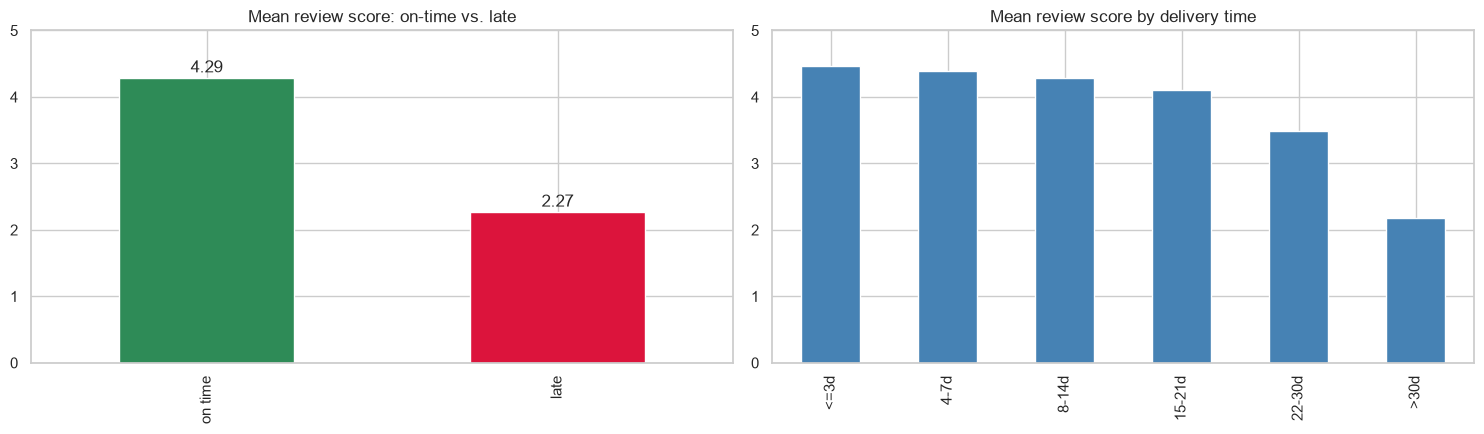

review_score    1    2    3    4    5
is_late                              
on time      0.07 0.03 0.08 0.20 0.62
late         0.54 0.09 0.11 0.10 0.17


In [45]:
# One review score per order (latest review), joined to delivery outcome
# rev_order = reviews.sort_values("review_creation_date").drop_duplicates("order_id", keep="last")[["order_id", "review_score"]] # kept most recent reviews if duplicated
dr = delivered.merge(rev_order, on="order_id", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
dr.groupby("is_late").review_score.mean().rename({False: "on time", True: "late"}).plot.bar(ax=axes[0], color=["seagreen", "crimson"])
axes[0].set_title("Mean review score: on-time vs. late"); axes[0].set_ylim(0, 5); axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 0.08, f"{p.get_height():.2f}", ha="center")

dr["delivery_bucket"] = pd.cut(dr.delivery_days, [-1, 3, 7, 14, 21, 30, 1000],
                               labels=["<=3d", "4-7d", "8-14d", "15-21d", "22-30d", ">30d"])
dr.groupby("delivery_bucket").review_score.mean().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("Mean review score by delivery time"); axes[1].set_ylim(0, 5); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

print(pd.crosstab(dr.is_late, dr.review_score, normalize="index").round(3).rename(index={False: "on time", True: "late"}))


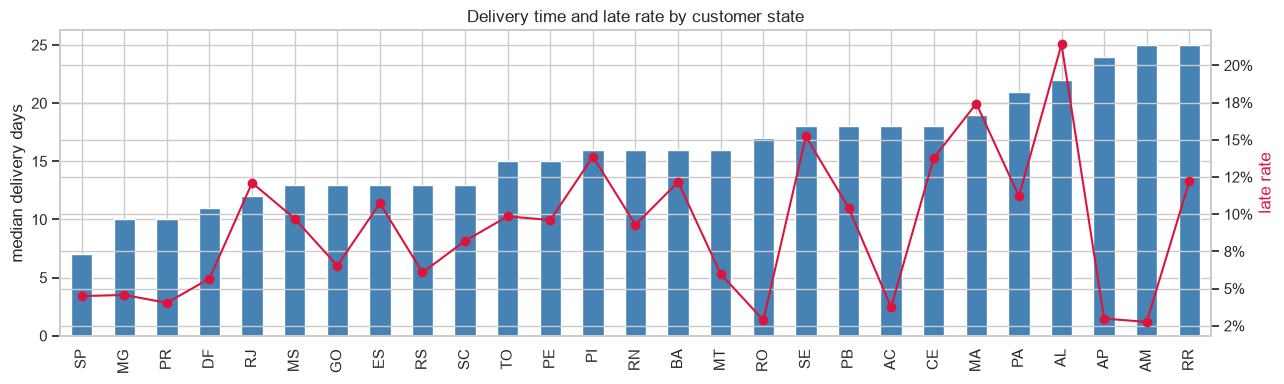

In [46]:
# Delivery time by customer state (bar and line plot)
dstate = (delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id")
          .groupby("customer_state").agg(median_days=("delivery_days", "median"), late_rate=("is_late", "mean"), n=("order_id", "size"))
          .sort_values("median_days"))
fig, ax = plt.subplots(figsize=(13, 4))
dstate.median_days.plot.bar(ax=ax, color="steelblue")
ax2 = ax.twinx()
dstate.late_rate.plot(ax=ax2, marker="o", color="crimson", lw=1.5)
ax.set_ylabel("median delivery days"); ax2.set_ylabel("late rate", color="crimson")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_title("Delivery time and late rate by customer state"); ax.set_xlabel("")
plt.tight_layout(); plt.show()


### 5.3 Where customers and sellers are

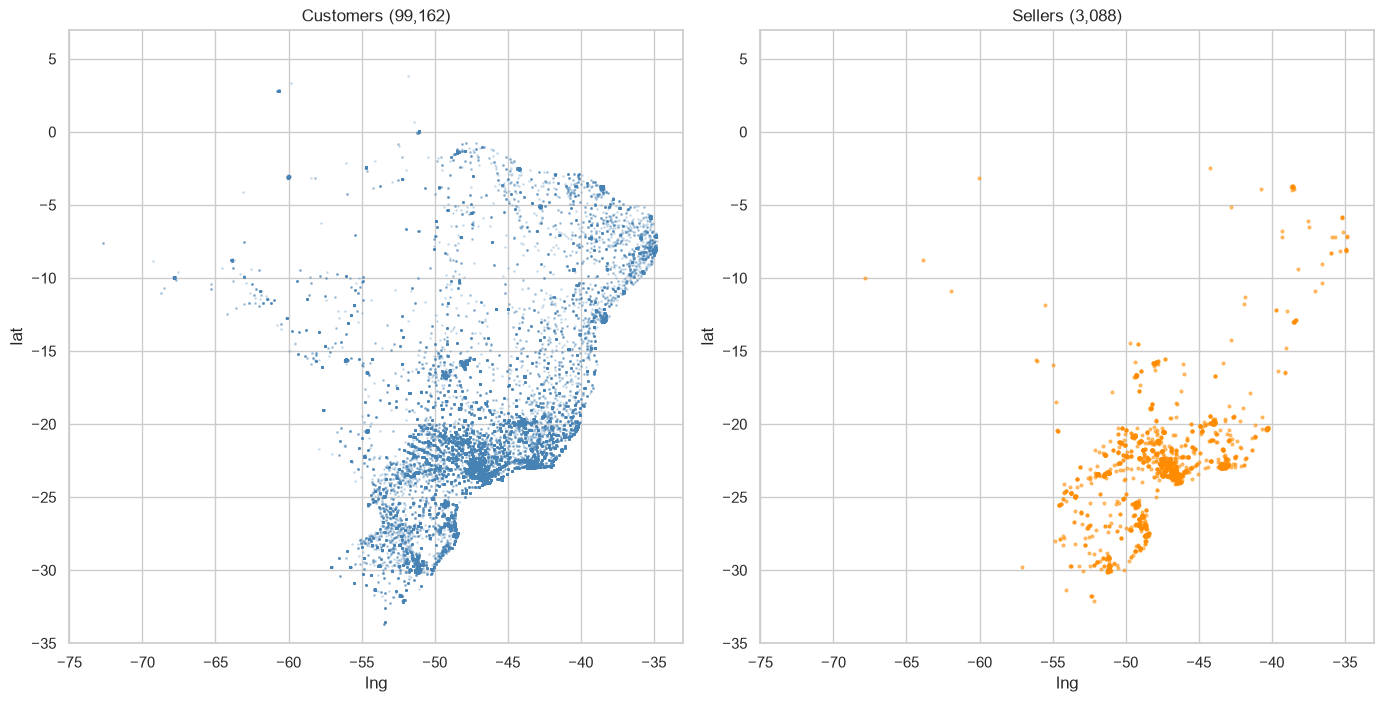

Items shipped within the same state: 36.2%
Items shipped from SP sellers: 71.3%


In [47]:
cust_pts = customers.merge(geo_zip, left_on="customer_zip_code_prefix", right_index=True)
sell_pts = sellers.merge(geo_zip, left_on="seller_zip_code_prefix", right_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].scatter(cust_pts.lng, cust_pts.lat, s=1, alpha=0.2, c="steelblue")
axes[0].set_title(f"Customers ({len(cust_pts):,})")
axes[1].scatter(sell_pts.lng, sell_pts.lat, s=4, alpha=0.5, c="darkorange")
axes[1].set_title(f"Sellers ({len(sell_pts):,})")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlabel("lng"); ax.set_ylabel("lat")
    ax.set_xlim(-75, -33); ax.set_ylim(-35, 7)
plt.tight_layout(); plt.show()

same_state = (full.customer_state == full.seller_state).mean()
print(f"Items shipped within the same state: {same_state:.1%}")
print(f"Items shipped from SP sellers: {(full.seller_state == 'SP').mean():.1%}")


In [48]:
df.to_csv(DATA_DIR + "smartcommerce_consolidated.csv", index=False)

## 6. Regional consumer behaviour

### 6.1 Order-level behaviour frame

In [49]:
# one row per payment-behaviour per order
pay_order = payments.groupby("order_id").agg(
    pay_value    = ("payment_value", "sum"),          # what the customer actually paid (incl. freight, vouchers)
    installments = ("payment_installments", "max"),
    n_payments   = ("payment_sequential", "max"),
    credit       = ("payment_type", lambda s: (s == "credit_card").any()),
    boleto       = ("payment_type", lambda s: (s == "boleto").any()),
    voucher      = ("payment_type", lambda s: (s == "voucher").any()),
)

# one row per order: basket metrics from line items
order_level = (df.groupby("order_id")
                 .agg(customer_state=("customer_state", "first"),
                      customer_unique_id=("customer_unique_id", "first"),
                      order_status=("order_status", "first"),
                      purchase_ts=("order_purchase_timestamp", "first"),
                      delivered_ts=("order_delivered_customer_date", "first"),
                      estimated_ts=("order_estimated_delivery_date", "first"),
                      n_items=("order_item_id", "max"),
                      n_categories=("category", "nunique"),
                      basket_value=("price", "sum"),
                      freight=("freight_value", "sum"),
                      weight_g=("product_weight_g", "sum"),
                      cross_state=("seller_state", lambda s: (s != s.iloc[0]).any()))  # placeholder, fixed below
                 .reset_index())
# cross-state = any item shipped from a different state than the customer's
order_level["cross_state"] = (df.assign(x=df.seller_state != df.customer_state)
                                .groupby("order_id").x.any().values)

order_level = (order_level
               .merge(pay_order, on="order_id", how="left")
               .merge(rev_order, on="order_id", how="left"))
order_level["delivery_days"]  = (order_level.delivered_ts - order_level.purchase_ts).dt.days
order_level["is_late"]        = np.where(order_level.delivered_ts.notna(),
                                         order_level.delivered_ts > order_level.estimated_ts, np.nan)
order_level["freight_ratio"]  = order_level.freight / order_level.basket_value
order_level["purchase_hour"]  = order_level.purchase_ts.dt.hour
order_level["is_weekend"]     = order_level.purchase_ts.dt.dayofweek >= 5
print(order_level.shape)
order_level.head(3)

(98666, 26)


,order_id,customer_state,customer_unique_id,order_status,purchase_ts,delivered_ts,estimated_ts,n_items,n_categories,basket_value,freight,weight_g,cross_state,pay_value,installments,n_payments,credit,boleto,voucher,review_score,review_creation_date,delivery_days,is_late,freight_ratio,purchase_hour,is_weekend
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,871766c5855e863f6eccc05f988b23cb,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,1,1,58.90,13.29,650.00,True,72.19,2.00,1.00,True,False,False,5.00,2017-09-21,7.00,0.00,0.23,8,False
1,00018f77f2f0320c557190d7a144bdd3,SP,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,1,1,239.90,19.93,"30,000.00",False,259.83,3.00,1.00,True,False,False,4.00,2017-05-13,16.00,0.00,0.08,10,False
2,000229ec398224ef6ca0657da4fc703e,MG,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,1,1,199.00,17.87,"3,050.00",False,216.87,5.00,1.00,True,False,False,5.00,2018-01-23,7.00,0.00,0.09,14,True


In [55]:
# --- 6.1b Per-order customer→seller shipping distance (zip-to-zip haversine) ---
def haversine_km(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lng2 - lng1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

it_dist = (items[["order_id", "seller_id"]]
           .merge(orders[["order_id", "customer_id"]], on="order_id")
           .merge(customers[["customer_id", "customer_zip_code_prefix"]], on="customer_id")
           .merge(sellers[["seller_id", "seller_zip_code_prefix"]], on="seller_id")
           .merge(geo_zip.add_prefix("cust_"), left_on="customer_zip_code_prefix", right_index=True, how="left")
           .merge(geo_zip.add_prefix("sell_"), left_on="seller_zip_code_prefix", right_index=True, how="left"))
it_dist["dist_km"] = haversine_km(it_dist.cust_lat, it_dist.cust_lng, it_dist.sell_lat, it_dist.sell_lng)
print(f"Items without coordinates (left NaN): {it_dist.dist_km.isna().mean():.2%}")

# order grain: the farthest item is the binding delivery leg
order_dist = it_dist.groupby("order_id").dist_km.max().rename("order_dist_km")
order_level = order_level.merge(order_dist, on="order_id", how="left")

# calendar month on order_level (needed by 6.5)
order_level["year_month"] = order_level.purchase_ts.dt.to_period("M")

print(f"Median order shipping distance: {order_level.order_dist_km.median():.0f} km  "
      f"(SP intra-state: {order_level.loc[order_level.customer_state == 'SP', 'order_dist_km'].median():.0f} km)")

Items without coordinates (left NaN): 0.49%
Median order shipping distance: 435 km  (SP intra-state: 164 km)


### 6.2 One behaviour profile per state

In [50]:
# repeat behaviour must be computed per person before aggregating
per_person = order_level.groupby(["customer_state", "customer_unique_id"]).order_id.count()
repeat_share = per_person.groupby("customer_state").apply(lambda s: (s > 1).mean())

state_beh = (order_level.groupby("customer_state")
             .agg(orders=("order_id", "size"),
                  aov=("pay_value", "mean"),                 # order grain -> true AOV
                  median_basket=("basket_value", "median"),
                  items_per_order=("n_items", "mean"),
                  avg_installments=("installments", "mean"),
                  credit_share=("credit", "mean"),
                  boleto_share=("boleto", "mean"),
                  voucher_share=("voucher", "mean"),
                  weekend_share=("is_weekend", "mean"),
                  cross_state_share=("cross_state", "mean"),
                  median_delivery_days=("delivery_days", "median"),
                  late_rate=("is_late", "mean"),             # NaN-safe: undelivered excluded
                  review_mean=("review_score", "mean")))
state_beh["freight_ratio"] = order_level.groupby("customer_state").apply(
    lambda g: g.freight.sum() / g.basket_value.sum())
state_beh["repeat_customer_share"] = repeat_share
state_beh = state_beh.sort_values("orders", ascending=False)
state_beh.round(3)

,orders,aov,median_basket,items_per_order,avg_installments,credit_share,boleto_share,voucher_share,weekend_share,cross_state_share,median_delivery_days,late_rate,review_mean,freight_ratio,repeat_customer_share
customer_state,,,,,,,,,,,,,,,
SP,41375,143.14,79.80,1.15,2.69,0.77,0.20,0.04,0.23,0.24,7.00,0.06,4.20,0.14,0.03
RJ,12762,166.90,89.99,1.14,3.06,0.80,0.17,0.04,0.24,0.92,12.00,0.14,3.89,0.17,0.03
MG,11544,160.82,89.90,1.14,3.06,0.78,0.20,0.04,0.23,0.87,10.00,0.06,4.15,0.17,0.03
RS,5432,163.14,89.00,1.15,3.04,0.73,0.25,0.03,0.23,0.95,13.00,0.07,4.15,0.18,0.03
PR,4998,160.29,84.99,1.15,2.94,0.75,0.22,0.04,0.23,0.85,10.00,0.05,4.20,0.17,0.03
SC,3612,168.96,89.90,1.16,2.93,0.74,0.23,0.03,0.22,0.93,13.00,0.10,4.09,0.17,0.03
BA,3358,182.14,94.90,1.13,3.34,0.78,0.18,0.05,0.24,0.98,16.00,0.14,3.88,0.20,0.03
DF,2125,166.24,87.99,1.13,2.77,0.79,0.18,0.04,0.22,0.98,11.00,0.07,4.08,0.17,0.03
ES,2025,160.41,89.00,1.11,3.06,0.77,0.20,0.04,0.23,1.00,13.00,0.12,4.05,0.18,0.03


States with <500 orders (merged into 'N-small' for charts): ['PI', 'RN', 'AL', 'SE', 'TO', 'RO', 'AM', 'AC', 'AP', 'RR']


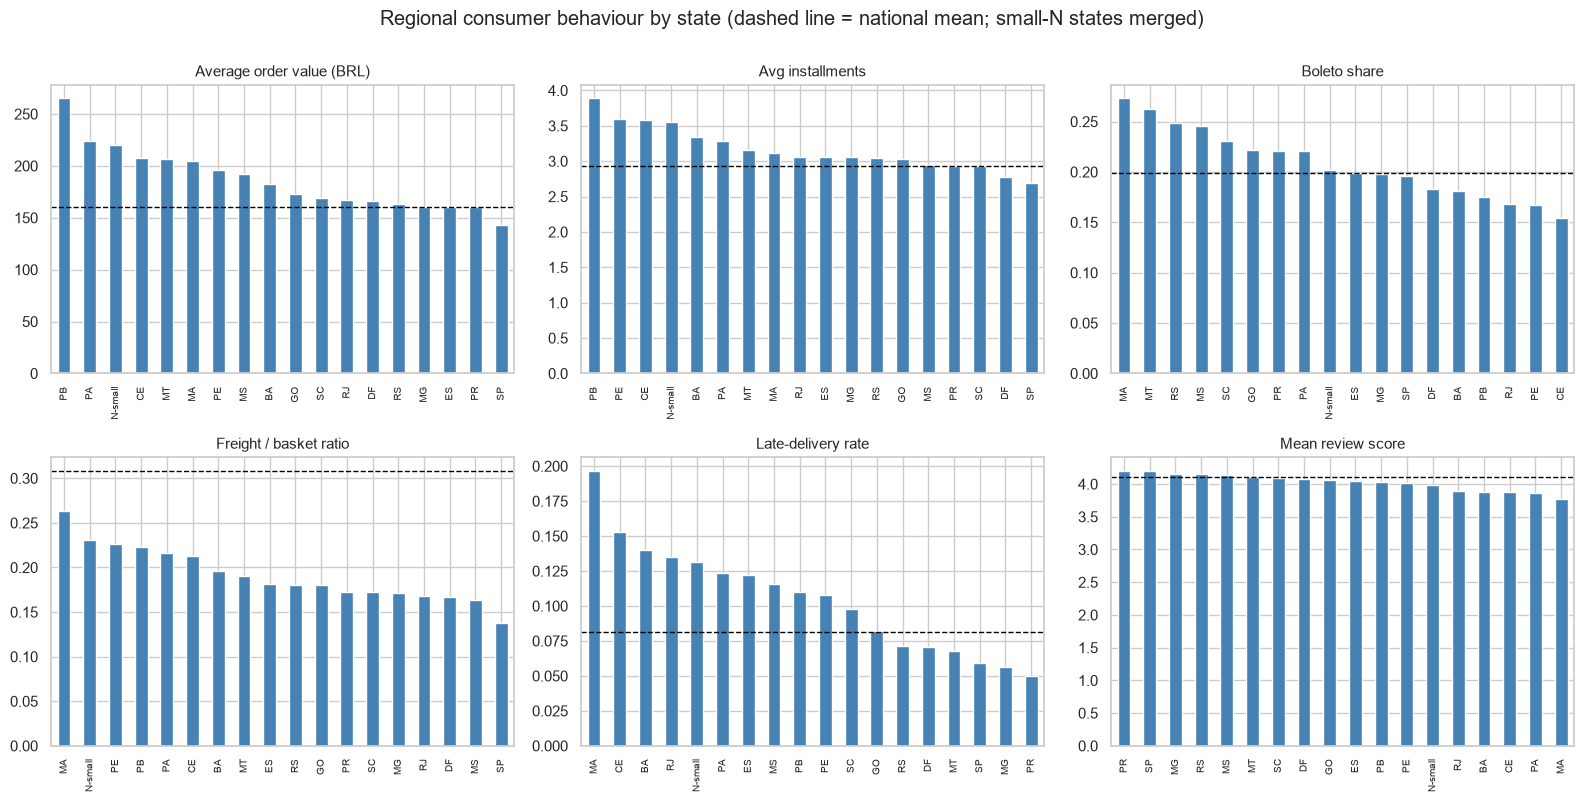

,orders,aov,avg_installments,boleto_share,late_rate,review_mean,repeat,freight_ratio
state_grp,,,,,,,,
SP,41375,143.14,2.69,0.20,0.06,4.20,0.03,0.14
RJ,12762,166.90,3.06,0.17,0.14,3.89,0.03,0.17
MG,11544,160.82,3.06,0.20,0.06,4.15,0.03,0.17
RS,5432,163.14,3.04,0.25,0.07,4.15,0.03,0.18
PR,4998,160.29,2.94,0.22,0.05,4.20,0.03,0.17
SC,3612,168.96,2.93,0.23,0.10,4.09,0.03,0.17
BA,3358,182.14,3.34,0.18,0.14,3.88,0.03,0.20
N-small,2599,220.16,3.55,0.20,0.13,3.98,0.03,0.23
DF,2125,166.24,2.77,0.18,0.07,4.08,0.03,0.17


In [51]:
# volumes are wildly uneven -> merge the noisy small-North states for regional comparisons
SMALL = state_beh.index[state_beh.orders < 500].tolist()
print("States with <500 orders (merged into 'N-small' for charts):", SMALL)
order_level["state_grp"] = order_level.customer_state.where(~order_level.customer_state.isin(SMALL), "N-small")

grp = (order_level.groupby("state_grp")
       .agg(orders=("order_id", "size"), aov=("pay_value", "mean"),
            avg_installments=("installments", "mean"), boleto_share=("boleto", "mean"),
            freight=("freight", "sum"), basket=("basket_value", "sum"),
            late_rate=("is_late", "mean"), review_mean=("review_score", "mean"),
            repeat=("customer_unique_id", lambda s: (s.value_counts() > 1).mean())))
grp["freight_ratio"] = grp.freight / grp.basket
grp = grp.drop(columns=["freight", "basket"]).sort_values("orders", ascending=False)

metrics = ["aov", "avg_installments", "boleto_share", "freight_ratio", "late_rate", "review_mean"]
titles  = ["Average order value (BRL)", "Avg installments", "Boleto share",
           "Freight / basket ratio", "Late-delivery rate", "Mean review score"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, metrics, titles):
    s = grp[m].sort_values(ascending=False)
    s.plot.bar(ax=ax, color="steelblue")
    ax.set_title(t, fontsize=11); ax.set_xlabel("")
    ax.axhline(order_level[{"aov": "pay_value", "avg_installments": "installments",
                            "boleto_share": "boleto", "freight_ratio": "freight_ratio",
                            "late_rate": "is_late", "review_mean": "review_score"}[m]].mean(),
               ls="--", color="black", lw=1)
    ax.tick_params(axis="x", labelsize=7)
fig.suptitle("Regional consumer behaviour by state (dashed line = national mean; small-N states merged)", y=1.00)
plt.tight_layout(); plt.show()
grp.round(3)

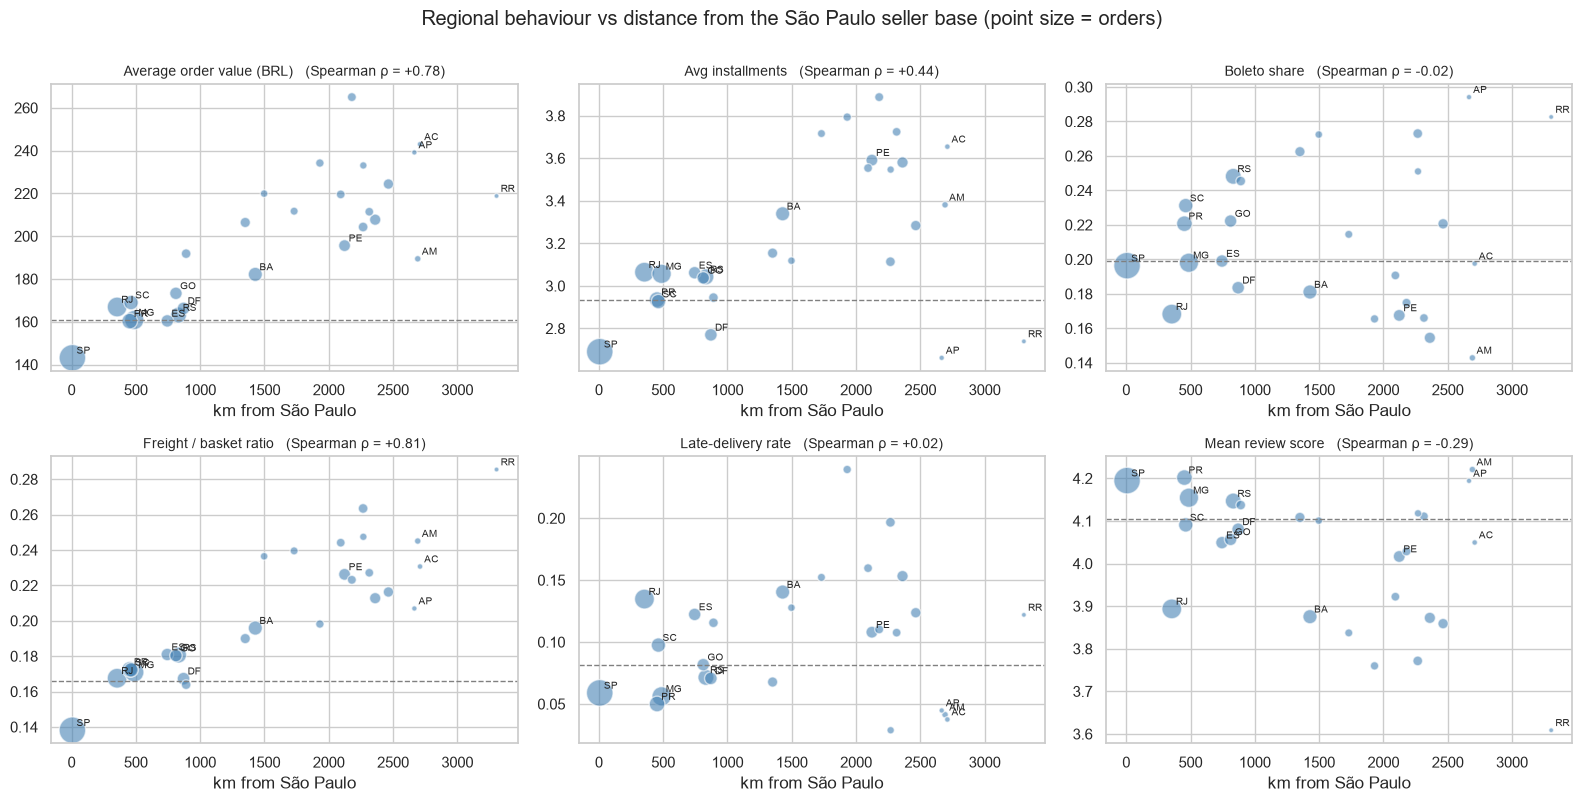

In [52]:
# --- Compute distance from SSão Paulo ---
g = geo[geo.geolocation_lat.between(-34, 6) & geo.geolocation_lng.between(-74, -34)]
cent = g.groupby("geolocation_state")[["geolocation_lat", "geolocation_lng"]].median()
SP_LAT, SP_LNG = -23.55, -46.63
lat1, lat2, dlng = map(np.radians, [SP_LAT, cent.geolocation_lat, cent.geolocation_lng - SP_LNG])
cent["dist_km"] = 6371 * 2 * np.arcsin(np.sqrt(
    np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2) ** 2))
state_beh = state_beh.join(cent["dist_km"])

# --- 6.2b Behaviour vs distance from the São Paulo seller base ---
nat = {"aov": order_level.pay_value.mean(), "avg_installments": order_level.installments.mean(),
       "boleto_share": order_level.boleto.mean(),
       "freight_ratio": order_level.freight.sum() / order_level.basket_value.sum(),
       "late_rate": order_level.is_late.mean(), "review_mean": order_level.review_score.mean()}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, metrics, titles):
    ax.scatter(state_beh.dist_km, state_beh[m], s=np.sqrt(state_beh.orders) * 1.8,
               alpha=.6, c="steelblue", edgecolor="white")
    for st, row in state_beh.iterrows():                      # label big markets + far North
        if row.orders > 1500 or row.dist_km > 2500:
            ax.annotate(st, (row.dist_km, row[m]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    rho = state_beh[["dist_km", m]].corr(method="spearman").iloc[0, 1]
    ax.axhline(nat[m], ls="--", color="gray", lw=1)
    ax.set_title(f"{t}   (Spearman ρ = {rho:+.2f})", fontsize=10)
    ax.set_xlabel("km from São Paulo")
fig.suptitle("Regional behaviour vs distance from the São Paulo seller base (point size = orders)", y=1.0)
plt.tight_layout(); plt.show()

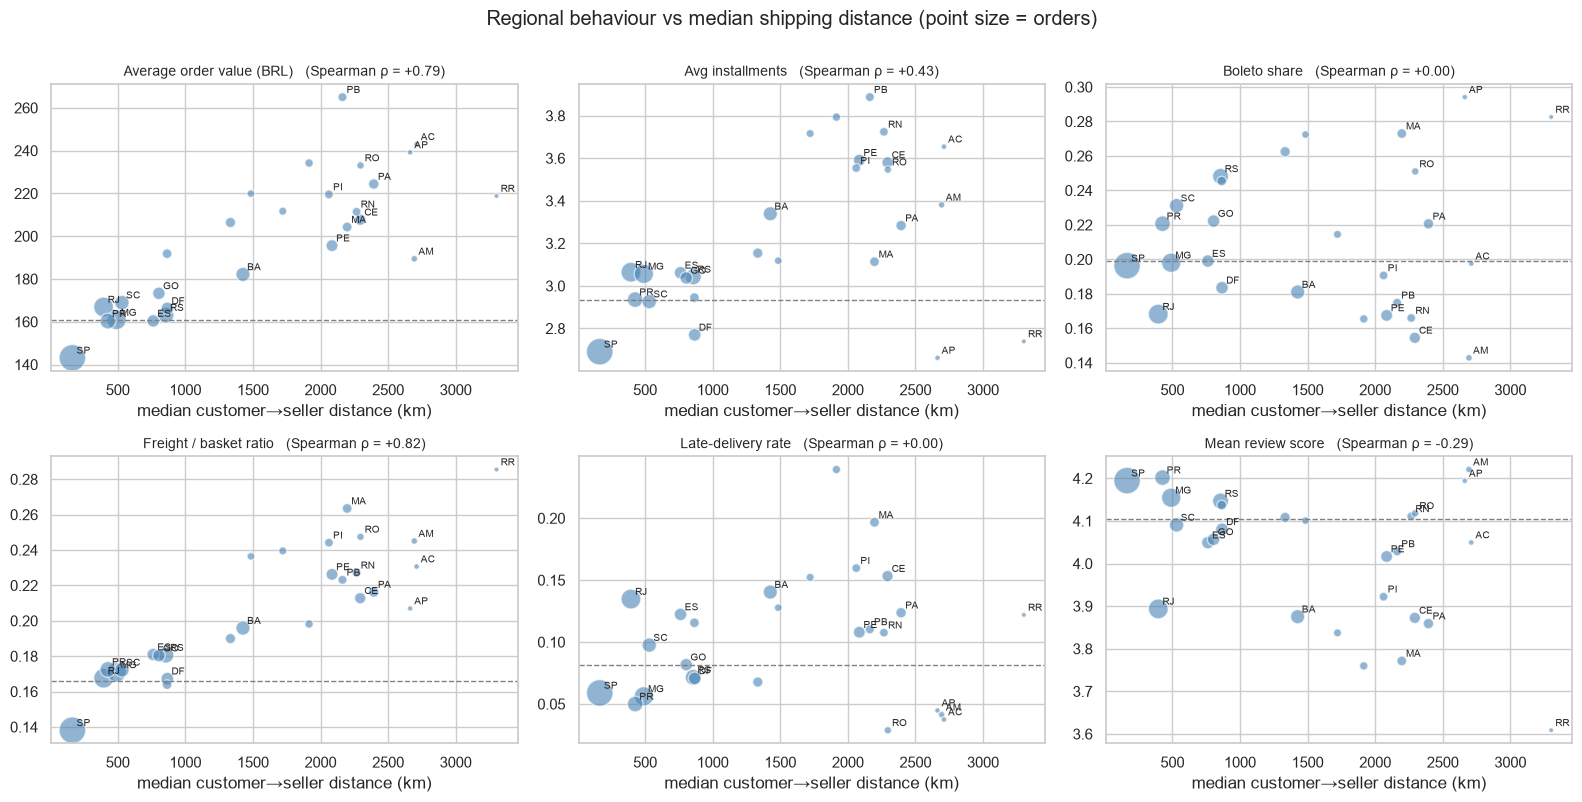

In [ ]:
# --- Behaviour vs median customer→seller shipping distance ---
state_beh["dist_km"] = order_level.groupby("customer_state").order_dist_km.median()

nat = {"aov": order_level.pay_value.mean(), "avg_installments": order_level.installments.mean(),
       "boleto_share": order_level.boleto.mean(),
       "freight_ratio": order_level.freight.sum() / order_level.basket_value.sum(),
       "late_rate": order_level.is_late.mean(), "review_mean": order_level.review_score.mean()}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, metrics, titles):
    ax.scatter(state_beh.dist_km, state_beh[m], s=np.sqrt(state_beh.orders) * 1.8,
               alpha=.6, c="steelblue", edgecolor="white")
    for st, row in state_beh.iterrows():
        if row.orders > 1500 or row.dist_km > 2000:
            ax.annotate(st, (row.dist_km, row[m]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    rho = state_beh[["dist_km", m]].corr(method="spearman").iloc[0, 1]
    ax.axhline(nat[m], ls="--", color="gray", lw=1)
    ax.set_title(f"{t}   (Spearman ρ = {rho:+.2f})", fontsize=10)
    ax.set_xlabel("median customer→seller distance (km)")
fig.suptitle("Regional behaviour vs median shipping distance (point size = orders)", y=1.0)
plt.tight_layout(); plt.show()

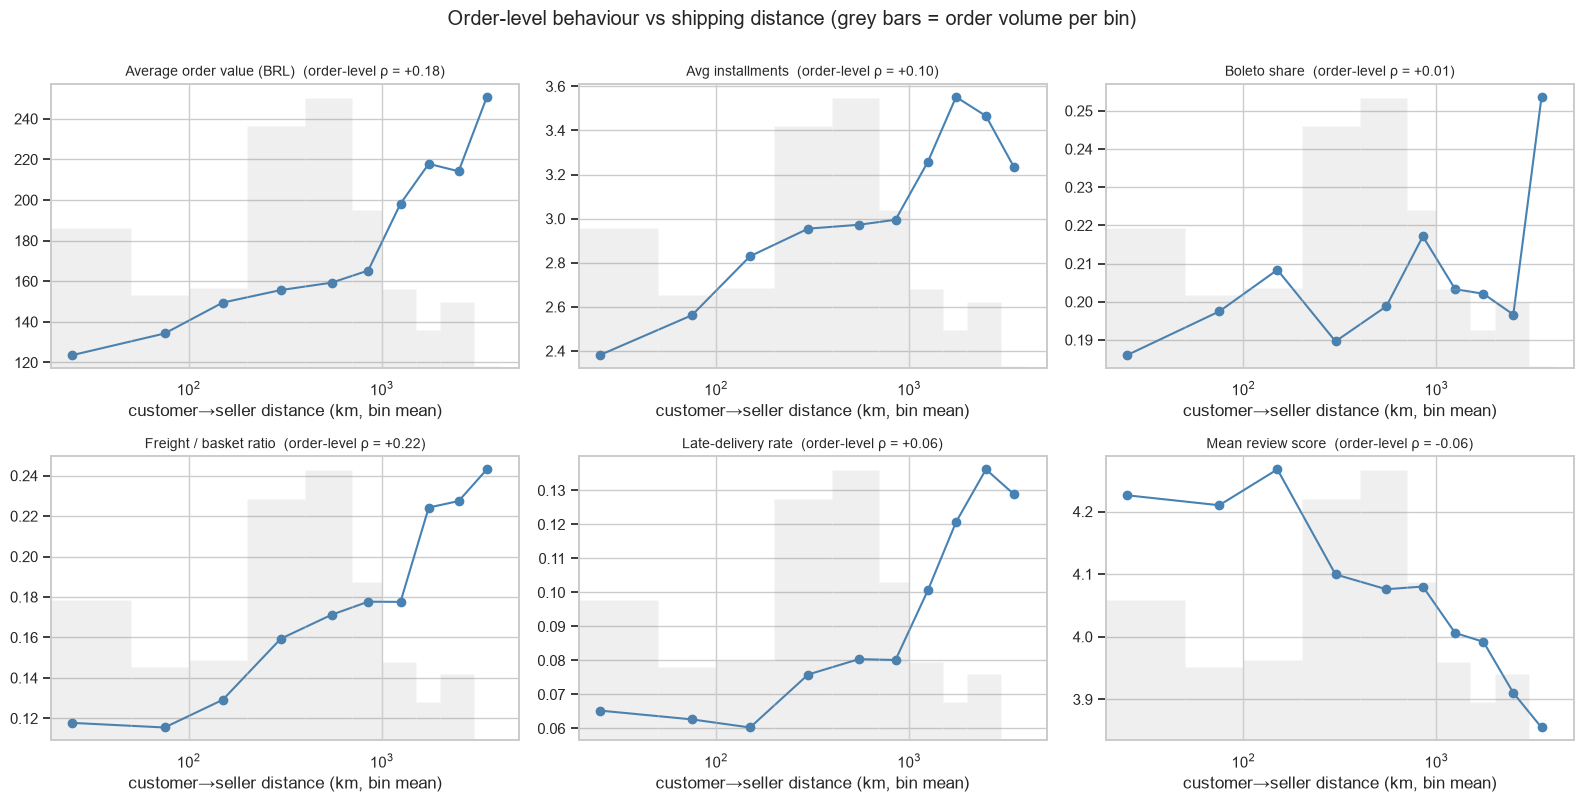

In [57]:
# --- 6.2c Order-level behaviour vs shipping distance (binned) ---
bins = [0, 50, 100, 200, 400, 700, 1000, 1500, 2000, 3000, 4000]
order_level["dist_bin"] = pd.cut(order_level.order_dist_km, bins)

bm = (order_level.groupby("dist_bin")
      .agg(n=("order_id", "size"), aov=("pay_value", "mean"),
           avg_installments=("installments", "mean"), boleto_share=("boleto", "mean"),
           late_rate=("is_late", "mean"), review_mean=("review_score", "mean"),
           f=("freight", "sum"), b=("basket_value", "sum")))
bm["freight_ratio"] = bm.f / bm.b
x = [iv.mid for iv in bm.index]

metric_col = {"aov": "pay_value", "avg_installments": "installments", "boleto_share": "boleto",
              "freight_ratio": "freight_ratio", "late_rate": "is_late", "review_mean": "review_score"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, m, t in zip(axes.flat, metrics, titles):
    rho = order_level[["order_dist_km", metric_col[m]]].dropna().corr(method="spearman").iloc[0, 1]
    ax.plot(x, bm[m], marker="o", color="steelblue")
    ax2 = ax.twinx()
    ax2.bar(x, bm.n, width=np.diff(bins), align="center", alpha=0.12, color="gray")
    ax2.set_yticks([])
    ax.set_xscale("log")
    ax.set_title(f"{t}  (order-level ρ = {rho:+.2f})", fontsize=10)
    ax.set_xlabel("customer→seller distance (km, bin mean)")
fig.suptitle("Order-level behaviour vs shipping distance (grey bars = order volume per bin)", y=1.0)
plt.tight_layout(); plt.show()

Average order value (AOV): mean per-order total of item prices plus customer-paid shipping fees (price + freight_value summed over the order's line items); equals item prices + shipping fees for 99.7% of orders).


### 6.3 What do different regions buy? Category mix

In [ ]:
top_cats = df.groupby("category").price.sum().nlargest(12).index
mix = (df[df.category.isin(top_cats)]
       .assign(state_grp=df.customer_state.where(~df.customer_state.isin(SMALL), "N-small"))
       .pivot_table(index="state_grp", columns="category", values="price", aggfunc="sum", fill_value=0))
mix_share = mix.div(mix.sum(axis=1), axis=0)                       # share of the state's own GMV
rel = mix_share.div(df[df.category.isin(top_cats)].groupby("category").price.sum()
                    .pipe(lambda s: s / s.sum()), axis=1)          # ...relative to the national mix

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(rel.loc[grp.index], cmap="RdBu_r", center=1, annot=True, fmt=".2f",
            cbar_kws={"label": "state share ÷ national share"}, ax=ax)
ax.set_title("Category preference index by state (1 = national average, >1 = over-indexes)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

### 6.4 Sales & popular items per state by month

In [ ]:
monthly_total = df.groupby("year_month").price.sum()
fig, ax = plt.subplots(figsize=(11, 3.5))
monthly_total.plot.bar(ax=ax, color=np.where(monthly_total.index.isin(
    [pd.Period("2016-09"), pd.Period("2016-10"), pd.Period("2016-12"), pd.Period("2018-09")]), "tomato", "steelblue"))
ax.set_title("Monthly item GMV — red months are unusable (near-empty or truncated)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xlabel(""); plt.xticks(rotation=60, fontsize=8)
plt.tight_layout(); plt.show()

WINDOW = (df.year_month >= "2017-01") & (df.year_month <= "2018-08")
ts = df[WINDOW].copy()
print(f"Usable: 2017-01..2018-08 = {ts.year_month.nunique()} months \n"
      f"-> at most ~17 supervised samples per series after a 1-month lag; \n"
      f"<2 yearly cycles, so yearly seasonality cannot be estimated, only flagged (Black Friday dummy).")

In [ ]:
# --- 6.4 Forecast target: state × month GMV ---
ts["state_grp"] = ts.customer_state.where(~ts.customer_state.isin(SMALL), "N-small")
panel = (ts.groupby(["state_grp", "year_month"])
           .agg(gmv=("price", "sum"),                       # TARGET: item GMV (goods only)
                gmv_incl_freight=("item_total_price", "sum"),
                orders=("order_id", "nunique"),
                items=("order_item_id", "size"))
           .reset_index()
           .sort_values(["state_grp", "year_month"]))
print(f"{len(panel)} state-month rows  |  log-corr(gmv, gmv incl. freight) = "
      f"{np.corrcoef(np.log1p(panel.gmv), np.log1p(panel.gmv_incl_freight))[0,1]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
sns.histplot(panel.gmv, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title(f"State×month GMV, raw (skew {panel.gmv.skew():.1f})")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
sns.histplot(np.log1p(panel.gmv), bins=40, ax=axes[1], color="steelblue")
axes[1].set_title(f"log1p(GMV) — model in this space (skew {np.log1p(panel.gmv).skew():.1f})")
ratio = panel.groupby("state_grp").apply(lambda g: g.gmv_incl_freight.sum() / g.gmv.sum()).sort_values()
ratio.plot.bar(ax=axes[2], color="indianred"); axes[2].axhline(1, color="black", lw=1)
axes[2].set_title("GMV incl. freight ÷ item GMV — freight is a state-dependent markup"); axes[2].set_xlabel("")
plt.tight_layout(); plt.show()

3rd panel justify why freight is not included in the per month analysis. -> due to strong state dependent driver

In [ ]:
sm = ts.groupby(["customer_state", "year_month"]).price.sum().unstack().fillna(0)
top20 = sm.sum(axis=1).nlargest(20).index

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sm.loc[top20].T.pipe(lambda d: d.set_axis(d.index.to_timestamp())).plot(ax=axes[0], marker=".", lw=1.2)
axes[0].set_yscale("log"); axes[0].set_title("Monthly revenue — top 20 states (log)")
axes[0].axvline(pd.Timestamp("2017-11-01"), color="gray", ls=":", lw=1)
axes[0].legend(ncol=2, fontsize=8)

growth = sm.loc[top20].T.pct_change().dropna()
sns.heatmap(growth.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Correlation of month-over-month growth")
plt.tight_layout(); plt.show()

lag1 = sm.loc[top20].T.apply(lambda s: s.autocorr(1)).rename("lag-1 autocorr")
print(lag1.round(2))

In [ ]:
nat = panel.groupby("year_month").gmv.sum().pct_change()
r2 = {}
for st, s in panel.pivot(index="year_month", columns="state_grp", values="gmv").pct_change().items():
    d = pd.concat([s, nat], axis=1).dropna()
    r2[st] = np.corrcoef(d.iloc[:, 0], d.iloc[:, 1])[0, 1] ** 2
pd.Series(r2).sort_values(ascending=False).plot.bar(figsize=(11, 3), title="R² of state growth on national growth")

High R² for the big states → a pooled model with a national trend and state-specific level (fixed effect) is the right architecture; low R² for small states → their idiosyncratic noise isn't forecastable, merge them.

### 6.5 Which signals predict next-month GMV within a state?

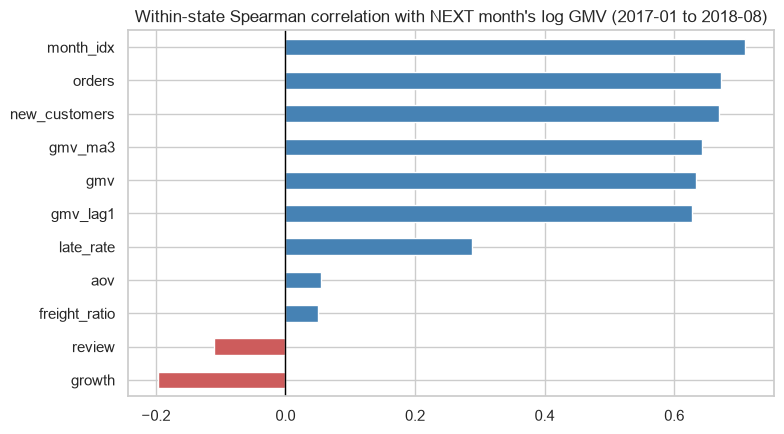

In [58]:
ol = order_level[(order_level.year_month >= "2017-01") & (order_level.year_month <= "2018-08")].copy()
first_seen = ol.groupby("customer_unique_id").year_month.min().rename("first_ym")
ol = ol.merge(first_seen, on="customer_unique_id")
ol["new_customer"] = ol.year_month == ol.first_ym
ol["state_grp"] = ol.customer_state.where(~ol.customer_state.isin(SMALL), "N-small")

feat_panel = (ol.groupby(["state_grp", "year_month"])
                .agg(gmv=("basket_value", "sum"), orders=("order_id", "size"), aov=("pay_value", "mean"),
                     new_customers=("new_customer", "sum"), late_rate=("is_late", "mean"),
                     review=("review_score", "mean"), freight_ratio=("freight_ratio", "mean"))
                .reset_index().sort_values(["state_grp", "year_month"]))
g = feat_panel.groupby("state_grp")
feat_panel["gmv_next"]  = g.gmv.shift(-1)
feat_panel["gmv_lag1"]  = g.gmv.shift(1)
feat_panel["gmv_ma3"]   = g.gmv.transform(lambda s: s.rolling(3).mean())
feat_panel["growth"]    = g.gmv.pct_change()
feat_panel["month_idx"] = (feat_panel.year_month - pd.Period("2017-01")).apply(lambda x: x.n)

feats = ["gmv", "gmv_lag1", "gmv_ma3", "orders", "new_customers", "aov", "growth",
         "late_rate", "review", "freight_ratio", "month_idx"]
d = feat_panel.dropna(subset=["gmv_next"]).copy()
for c in ["gmv", "gmv_next", "gmv_lag1", "gmv_ma3", "orders", "new_customers"]:
    d[c] = np.log1p(d[c])
within = d[feats + ["gmv_next"]].sub(d.groupby("state_grp")[feats + ["gmv_next"]].transform("mean"))
lead_corr = within.corr(method="spearman")["gmv_next"].drop("gmv_next").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
lead_corr.plot.barh(ax=ax, color=np.where(lead_corr > 0, "steelblue", "indianred"))
ax.set_title("Within-state Spearman correlation with NEXT month's log GMV (2017-01 to 2018-08)")
ax.axvline(0, color="black", lw=1)
plt.tight_layout(); plt.show()

score = proportion of state's spending on category / proportion of national spending on category \
health_beauty takes up 66% more of PB's spending than it does of national spending — 22.3% of top-12 spending, 1.66× its 13.4% national share.

## 6. Key takeaways

**Data quality**
- The nine tables join cleanly on `order_id`, `customer_id`, `product_id` and `seller_id` — effectively zero orphan keys. The only soft link is zip prefix → geolocation, where a small share of prefixes has no coordinates.
- `customer_id` is one-per-order; use `customer_unique_id` to identify people. Repeat buying is rare (~3%).
- `geolocation` holds raw coordinate observations (with duplicates and a few points outside Brazil); aggregate to one point per zip prefix before joining.
- `review_id` is not unique and some orders carry multiple reviews — deduplicate before joining to orders.
- Product category names are Portuguese; the translation table covers all but two categories, and ~2% of products have no category at all.

**Business picture**
- ~99k orders, Sep 2016 → Aug 2018, ~97% delivered. Volume grows steadily through 2017, peaks around Nov 2017 (Black Friday) and plateaus in 2018.
- Purchases cluster on weekdays and in the afternoon/evening; Saturdays and Sundays are the quietest days.
- Most orders contain a single item; item prices are heavily right-skewed (median ≈ R$75). Freight is a meaningful share of price, and is highest for the North/Northeast states far from the São Paulo seller base.
- Credit card dominates payments (~74%), with boleto second; multi-installment plans are common.
- Reviews skew positive (mean ≈ 4.1, >55% five-star), but score drops sharply with delivery delay: late orders average roughly 2 points lower than on-time ones. Delivery time is the single strongest lever visible in the data.
- Median delivery is about 10 days, with ~7% of deliveries arriving after the estimated date; the late rate spikes in early 2018.
- Sellers are concentrated in São Paulo state, and a small share of sellers accounts for most GMV.
